# **Zomato Restaurant Clustering and Sentiment Analysis**




##### **Project Type**    -  Unsupervised Learning (Clustering) + NLP Sentiment Analysis
##### **Contribution**    - Individual
##### Team Member 1 -Santhiya K


# **Project Summary -**

Zomato is an Indian restaurant aggregator and food delivery platform founded by Deepinder Goyal and Pankaj Chaddah in 2008. It provides restaurant information, menus, user reviews, and food delivery options across Indian cities. Given India's vast culinary diversity, Zomato's restaurant and review data offers rich insight into how the food industry behaves city by city.

This project works with two linked datasets: a **restaurant metadata** file (105 restaurants in Hyderabad with cost, cuisines, collections/tags, and timings) and a **customer reviews** file (10,000 reviews across 100 of those restaurants, with reviewer identity, review text, star rating, reviewer metadata, timestamp, and picture counts).

The project is split into two complementary analytical tracks that mirror the two stakeholders Zomato serves — **customers** and **the company** itself.

**Track 1 — Sentiment Analysis (Customer side).** Review text was cleaned (lower-casing, punctuation/URL/digit removal, stopword removal, lemmatization) and each review was assigned a sentiment label derived from its star rating (Positive for 4-5, Neutral for 3, Negative for 1-2). After dropping 46 corrupted/blank rows (38 fully-null rows plus one row with a shifted "Like" value in the Rating column and 36 exact duplicate reviews), roughly 63% of the cleaned reviews were Positive, 25% Negative, and 12% Neutral — showing an overall favourable customer sentiment but with a meaningful complaint volume worth investigating. Reviewer metadata (e.g. "3 Reviews, 2 Followers") was parsed into numeric `Reviewer_Review_Count` and `Reviewer_Follower_Count` fields to separately identify highly active reviewers/critics in the data. TF-IDF vectorization was applied to the cleaned text, and a Multinomial Naive Bayes, Logistic Regression, and Random Forest classifier were trained to predict sentiment from review text, giving Zomato a reusable tool to auto-tag the sentiment of any future review.

**Track 2 — Restaurant Clustering (Company side).** Restaurant-level features were engineered by aggregating the review data up to restaurant granularity (average rating, review volume, % positive reviews) and joining it back to the metadata (cost for two, cuisine count, collection tags). After scaling, K-Means clustering (validated using the elbow method and silhouette score, with k=3 giving the best silhouette score of ~0.39) grouped the 100 restaurants into three distinct segments: a large **Budget/Value** cluster (lower cost, average ratings, moderate positive sentiment), a small **Premium-Low-Visibility** cluster (high cost, strong ratings, but few reviews), and a **Premium-High-Performer** cluster (higher cost, the highest average rating and the highest share of positive sentiment, with wide cuisine variety). These segments give Zomato a direct way to recommend the "best restaurant in a locality" by segment and to flag underperforming budget restaurants that need cost-vs-quality intervention.

Together, the two tracks deliver on the original brief: sentiment-driven insight into how customers feel, and a segmentation that helps both customers find the best restaurant nearby and the company identify which fields (cost, cuisine range, review engagement) restaurants are lagging in.Write the summary here within 500-600 words.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


Zomato hosts thousands of restaurant listings and customer reviews across Indian cities, but this data is not being used to its full potential. Two business problems are addressed in this project:

1. **Customer sentiment is unstructured.** Reviews are free text, so there is no quick way to know what proportion of customers are happy, neutral, or unhappy with a restaurant, or what specific themes (service, ambience, food quality) drive negative sentiment. Customers also need a fast way to identify the "best restaurant in their locality" instead of reading hundreds of reviews.
2. **Restaurants are not segmented.** Zomato currently lists restaurants individually, with no grouping by cost, cuisine variety, and customer satisfaction. This makes it hard for the company to identify which restaurants are under-performing for their price tier, and which segments to recommend to which type of customer.

This project uses **sentiment analysis** on the review text to classify customer opinion, and **unsupervised clustering** on restaurant-level features (cost, cuisine count, rating, review volume, sentiment) to segment Hyderabad's restaurants into meaningful groups — enabling both better customer recommendations and clearer business insight for Zomato.
**Write Problem Statement Here.**

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [147]:
# Import Libraries
# Import Libraries

# Core data handling
import pandas as pd
import numpy as np
import re
import string
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid') if 'seaborn-v0_8-whitegrid' in plt.style.available else plt.style.use('ggplot')

# NLP
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

# Machine Learning - preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer

# Machine Learning - clustering (Unsupervised)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

# Machine Learning - classification (Sentiment)
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, roc_curve, auc)

# Statistical testing
from scipy import stats

# Model persistence
import pickle

print("All libraries imported successfully.")

All libraries imported successfully.


### Dataset Loading

In [148]:
# Load Dataset

# Restaurant metadata: name, cost, cuisines, collections/tags, timings
from google.colab import drive
drive.mount('/content/drive')
restaurant_df = pd.read_csv('/content/drive/MyDrive/Dataset/Zomato Restaurant names and Metadata.csv')

# Customer reviews: restaurant, reviewer, review text, rating, reviewer metadata, time, pictures
reviews_df =  pd.read_csv('/content/drive/MyDrive/Dataset/Zomato Restaurant reviews.csv')

print("Restaurant metadata loaded:", restaurant_df.shape)
print("Reviews data loaded:", reviews_df.shape)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Restaurant metadata loaded: (105, 6)
Reviews data loaded: (10000, 7)


### Dataset First View

In [149]:
# Dataset First Look

print("====== Restaurant Metadata - First 5 Rows ======")
display(restaurant_df.head())

print("\n====== Reviews Data - First 5 Rows ======")
display(reviews_df.head())

====== Restaurant Metadata - First 5 Rows ======


,Name,Links,Cost,Collections,Cuisines,Timings
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
1,Paradise,https://www.zomato.com/hyderabad/paradise-gach...,800,Hyderabad's Hottest,"Biryani, North Indian, Chinese",11 AM to 11 PM
2,Flechazo,https://www.zomato.com/hyderabad/flechazo-gach...,"1,300","Great Buffets, Hyderabad's Hottest","Asian, Mediterranean, North Indian, Desserts","11:30 AM to 4:30 PM, 6:30 PM to 11 PM"
3,Shah Ghouse Hotel & Restaurant,https://www.zomato.com/hyderabad/shah-ghouse-h...,800,Late Night Restaurants,"Biryani, North Indian, Chinese, Seafood, Bever...",12 Noon to 2 AM
4,Over The Moon Brew Company,https://www.zomato.com/hyderabad/over-the-moon...,"1,200","Best Bars & Pubs, Food Hygiene Rated Restauran...","Asian, Continental, North Indian, Chinese, Med...","12noon to 11pm (Mon, Tue, Wed, Thu, Sun), 12no..."



====== Reviews Data - First 5 Rows ======


,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0


### Dataset Rows & Columns count

In [150]:
# Dataset Rows & Columns count

print("Restaurant Metadata -> Rows: {}, Columns: {}".format(restaurant_df.shape[0], restaurant_df.shape[1]))
print("Reviews Data        -> Rows: {}, Columns: {}".format(reviews_df.shape[0], reviews_df.shape[1]))

Restaurant Metadata -> Rows: 105, Columns: 6
Reviews Data        -> Rows: 10000, Columns: 7


In [151]:
# Column names of both datasets
print("Restaurant Metadata columns:", list(restaurant_df.columns))
print("Reviews Data columns:", list(reviews_df.columns))

Restaurant Metadata columns: ['Name', 'Links', 'Cost', 'Collections', 'Cuisines', 'Timings']
Reviews Data columns: ['Restaurant', 'Reviewer', 'Review', 'Rating', 'Metadata', 'Time', 'Pictures']


### Dataset Information

In [152]:
# Dataset Info

print("====== Restaurant Metadata Info ======")
restaurant_df.info()

print("\n====== Reviews Data Info ======")
reviews_df.info()

====== Restaurant Metadata Info ======
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Name         105 non-null    object
 1   Links        105 non-null    object
 2   Cost         105 non-null    object
 3   Collections  51 non-null     object
 4   Cuisines     105 non-null    object
 5   Timings      104 non-null    object
dtypes: object(6)
memory usage: 5.1+ KB

====== Reviews Data Info ======
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Restaurant  10000 non-null  object
 1   Reviewer    9962 non-null   object
 2   Review      9955 non-null   object
 3   Rating      9962 non-null   object
 4   Metadata    9962 non-null   object
 5   Time        9962 non-null   object
 6   Pictures    10000 non-nu

#### Duplicate Values

In [153]:
# Dataset Duplicate Value Count

print("Duplicate rows in Restaurant Metadata:", restaurant_df.duplicated().sum())
print("Duplicate rows in Reviews Data:", reviews_df.duplicated().sum())

# Inspect a sample of the duplicate review rows
reviews_df[reviews_df.duplicated(keep=False)].sort_values(by=['Restaurant','Reviewer']).head(6)

Duplicate rows in Restaurant Metadata: 0
Duplicate rows in Reviews Data: 36


,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
8777,American Wild Wings,NaN,NaN,NaN,NaN,NaN,0
8778,American Wild Wings,NaN,NaN,NaN,NaN,NaN,0
8779,American Wild Wings,NaN,NaN,NaN,NaN,NaN,0
8780,American Wild Wings,NaN,NaN,NaN,NaN,NaN,0
8781,American Wild Wings,NaN,NaN,NaN,NaN,NaN,0
8782,American Wild Wings,NaN,NaN,NaN,NaN,NaN,0


#### Missing Values/Null Values

In [154]:
# Missing Values/Null Values Count

print("====== Missing Values - Restaurant Metadata ======")
print(restaurant_df.isnull().sum())

print("\n====== Missing Values - Reviews Data ======")
print(reviews_df.isnull().sum())

====== Missing Values - Restaurant Metadata ======
Name            0
Links           0
Cost            0
Collections    54
Cuisines        0
Timings         1
dtype: int64

====== Missing Values - Reviews Data ======
Restaurant     0
Reviewer      38
Review        45
Rating        38
Metadata      38
Time          38
Pictures       0
dtype: int64


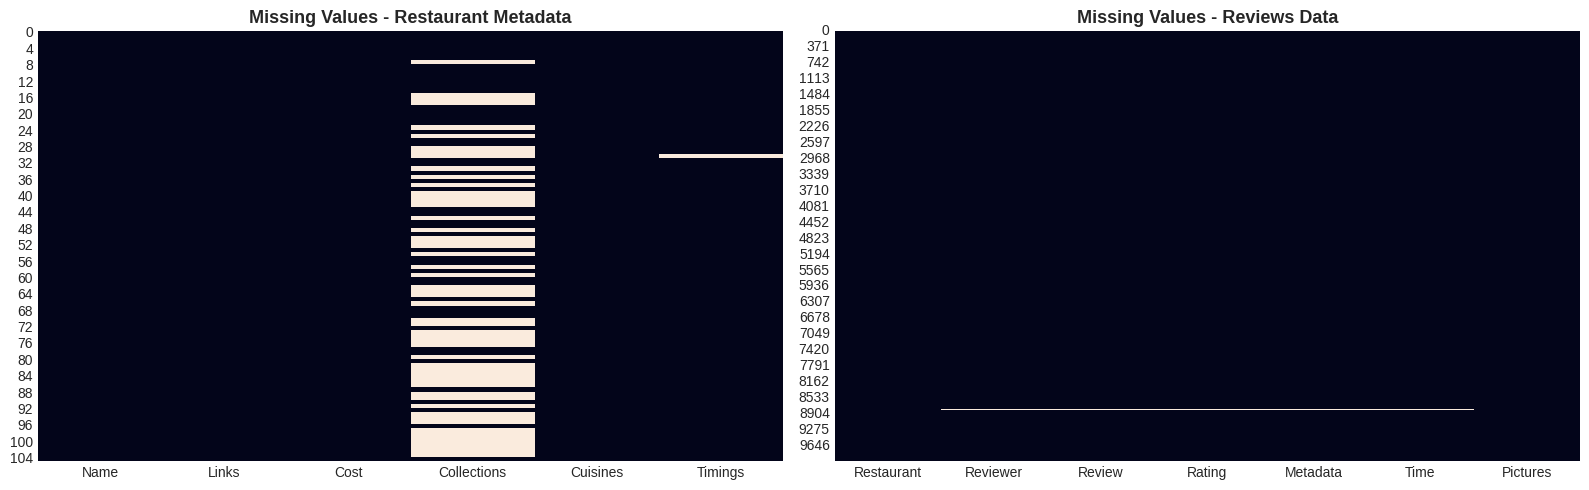

In [155]:
# Visualizing the missing values

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(restaurant_df.isnull(), cbar=False, cmap='rocket', ax=axes[0])
axes[0].set_title('Missing Values - Restaurant Metadata', fontsize=13, fontweight='bold')

sns.heatmap(reviews_df.isnull(), cbar=False, cmap='rocket', ax=axes[1])
axes[1].set_title('Missing Values - Reviews Data', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

### What did you know about your dataset?

**Restaurant Metadata (105 rows, 6 columns):** Contains `Name`, `Links` (Zomato URL), `Cost` (cost for two, stored as text with commas), `Collections` (Zomato's editorial tags, 54 missing — meaning those restaurants simply aren't tagged into any curated collection), `Cuisines` (comma-separated list), and `Timings` (1 missing). No duplicate rows.

**Reviews Data (10,000 rows, 7 columns):** Contains `Restaurant`, `Reviewer`, `Review` (free text), `Rating` (stored as text — mixes numeric strings with an erroneous "Like" value caused by a row-shift error), `Metadata` (reviewer's own review/follower counts as free text), `Time`, and `Pictures` (numeric). 38 rows are fully blank (no reviewer/review/rating/metadata/time, only restaurant name and 0 pictures present), suggesting scraping gaps rather than genuine zero-content reviews. There are 36 exact duplicate rows that need removing before analysis. All 100 restaurant names appearing in the reviews data also exist in the metadata file, so the two tables join cleanly on restaurant name — 5 restaurants in the metadata simply have no reviews recorded.

Overall, the data is reasonably clean for a real-world scrape, but requires: type conversion (`Cost`, `Rating` to numeric), removal of corrupted/duplicate/blank rows, and parsing of the semi-structured `Metadata` field before it's analysis-ready.

## ***2. Understanding Your Variables***

In [156]:
# Dataset Columns

print("Restaurant Metadata columns:\n", restaurant_df.columns.tolist())
print("\nReviews Data columns:\n", reviews_df.columns.tolist())

Restaurant Metadata columns:
 ['Name', 'Links', 'Cost', 'Collections', 'Cuisines', 'Timings']

Reviews Data columns:
 ['Restaurant', 'Reviewer', 'Review', 'Rating', 'Metadata', 'Time', 'Pictures']


In [157]:
# Dataset Describe

print("====== Restaurant Metadata - Describe (object columns) ======")
display(restaurant_df.describe(include='all'))

print("\n====== Reviews Data - Describe (object columns) ======")
display(reviews_df.describe(include='all'))

====== Restaurant Metadata - Describe (object columns) ======


,Name,Links,Cost,Collections,Cuisines,Timings
count,105,105,105,51,105,104
unique,105,105,29,42,92,77
top,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,500,Food Hygiene Rated Restaurants in Hyderabad,"North Indian, Chinese",11 AM to 11 PM
freq,1,1,13,4,4,6



====== Reviews Data - Describe (object columns) ======


,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
count,10000,9962,9955,9962,9962,9962,10000.000000
unique,100,7446,9364,10,2477,9782,NaN
top,Beyond Flavours,Parijat Ray,good,5,1 Review,7/29/2018 20:34,NaN
freq,100,13,237,3832,919,3,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,0.748600
std,NaN,NaN,NaN,NaN,NaN,NaN,2.570381
min,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,0.000000


### Variables Description

**Restaurant Metadata**
| Field | Description |
|---|---|
| Name | Name of the restaurant |
| Links | URL link of the restaurant on Zomato |
| Cost | Per-person estimated cost of dining (₹) |
| Collections | Zomato's editorial tagging/category of the restaurant |
| Cuisines | Cuisines served by the restaurant |
| Timings | Operating hours |

**Reviews Data**
| Field | Description |
|---|---|
| Restaurant | Name of the restaurant being reviewed |
| Reviewer | Name of the reviewer |
| Review | Free-text review content |
| Rating | Star rating given (1-5) |
| Metadata | Reviewer's own activity — number of reviews written & followers |
| Time | Date and time the review was posted |
| Pictures | Number of pictures posted with the review |

### Check Unique Values for each variable.

In [158]:
# Check Unique Values for each variable.

print("====== Unique value counts - Restaurant Metadata ======")
for col in restaurant_df.columns:
    print(f"{col}: {restaurant_df[col].nunique()} unique values")

print("\n====== Unique value counts - Reviews Data ======")
for col in reviews_df.columns:
    print(f"{col}: {reviews_df[col].nunique()} unique values")

print("\nUnique Rating values (raw, before cleaning):")
print(reviews_df['Rating'].unique())

====== Unique value counts - Restaurant Metadata ======
Name: 105 unique values
Links: 105 unique values
Cost: 29 unique values
Collections: 42 unique values
Cuisines: 92 unique values
Timings: 77 unique values

====== Unique value counts - Reviews Data ======
Restaurant: 100 unique values
Reviewer: 7446 unique values
Review: 9364 unique values
Rating: 10 unique values
Metadata: 2477 unique values
Time: 9782 unique values
Pictures: 36 unique values

Unique Rating values (raw, before cleaning):
['5' '4' '1' '3' '2' '3.5' '4.5' '2.5' '1.5' 'Like' nan]


## 3. ***Data Wrangling***

### Data Wrangling Code

In [159]:
# Write your code to make your dataset analysis ready.

# ---------- 1. Clean Reviews Data ----------
reviews_clean = reviews_df.copy()

# Drop fully blank rows (no reviewer/review/rating recorded)
reviews_clean = reviews_clean.dropna(subset=['Reviewer', 'Review', 'Rating'])

# Drop the single row where 'Rating' contains the erroneous text 'Like' (column-shift artifact)
reviews_clean = reviews_clean[reviews_clean['Rating'] != 'Like']

# Drop exact duplicate review rows
reviews_clean = reviews_clean.drop_duplicates()

# Convert Rating to numeric
reviews_clean['Rating'] = reviews_clean['Rating'].astype(float)

# Convert Time to datetime
reviews_clean['Time'] = pd.to_datetime(reviews_clean['Time'], errors='coerce')

# Parse the reviewer 'Metadata' field (e.g. "3 Reviews , 2 Followers") into numeric columns
def parse_reviewer_metadata(text):
    if pd.isna(text):
        return pd.Series([0, 0])
    reviews_n, followers_n = 0, 0
    for part in str(text).split(','):
        part = part.strip().lower()
        digits = ''.join(ch for ch in part if ch.isdigit())
        if 'review' in part:
            reviews_n = int(digits) if digits else 0
        elif 'follower' in part:
            followers_n = int(digits) if digits else 0
    return pd.Series([reviews_n, followers_n])

reviews_clean[['Reviewer_Review_Count', 'Reviewer_Follower_Count']] = reviews_clean['Metadata'].apply(parse_reviewer_metadata)

# Create a Sentiment label directly from the star rating
def get_sentiment(rating):
    if rating >= 4:
        return 'Positive'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Negative'

reviews_clean['Sentiment'] = reviews_clean['Rating'].apply(get_sentiment)

reviews_clean = reviews_clean.reset_index(drop=True)

print("Reviews data after wrangling:", reviews_clean.shape)
display(reviews_clean.head())

# ---------- 2. Clean Restaurant Metadata ----------
restaurant_clean = restaurant_df.copy()

# Cost is stored as text with thousand-separators e.g. "1,300" -> convert to numeric
restaurant_clean['Cost'] = restaurant_clean['Cost'].astype(str).str.replace(',', '').astype(float)

# Fill missing Collections with a explicit 'Not Tagged' label (absence of a tag is meaningful, not random)
restaurant_clean['Collections'] = restaurant_clean['Collections'].fillna('Not Tagged')

# Drop the single row with missing Timings (only 1 row affected)
restaurant_clean = restaurant_clean.dropna(subset=['Timings'])

# Engineer cuisine count per restaurant
restaurant_clean['Cuisine_Count'] = restaurant_clean['Cuisines'].apply(lambda x: len(str(x).split(',')))

restaurant_clean = restaurant_clean.reset_index(drop=True)

print("\nRestaurant metadata after wrangling:", restaurant_clean.shape)
display(restaurant_clean.head())

# ---------- 3. Merge into a single analysis-ready review-level table ----------
master_df = pd.merge(reviews_clean, restaurant_clean, left_on='Restaurant', right_on='Name', how='inner')
master_df = master_df.drop(columns=['Name'])

print("\nMerged master dataset (review level):", master_df.shape)
display(master_df.head())

Reviews data after wrangling: (9954, 10)


,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures,Reviewer_Review_Count,Reviewer_Follower_Count,Sentiment
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5.0,"1 Review , 2 Followers",2019-05-25 15:54:00,0,1,2,Positive
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5.0,"3 Reviews , 2 Followers",2019-05-25 14:20:00,0,3,2,Positive
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5.0,"2 Reviews , 3 Followers",2019-05-24 22:54:00,0,2,3,Positive
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5.0,"1 Review , 1 Follower",2019-05-24 22:11:00,0,1,1,Positive
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5.0,"3 Reviews , 2 Followers",2019-05-24 21:37:00,0,3,2,Positive



Restaurant metadata after wrangling: (104, 7)


,Name,Links,Cost,Collections,Cuisines,Timings,Cuisine_Count
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800.0,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",6
1,Paradise,https://www.zomato.com/hyderabad/paradise-gach...,800.0,Hyderabad's Hottest,"Biryani, North Indian, Chinese",11 AM to 11 PM,3
2,Flechazo,https://www.zomato.com/hyderabad/flechazo-gach...,1300.0,"Great Buffets, Hyderabad's Hottest","Asian, Mediterranean, North Indian, Desserts","11:30 AM to 4:30 PM, 6:30 PM to 11 PM",4
3,Shah Ghouse Hotel & Restaurant,https://www.zomato.com/hyderabad/shah-ghouse-h...,800.0,Late Night Restaurants,"Biryani, North Indian, Chinese, Seafood, Bever...",12 Noon to 2 AM,5
4,Over The Moon Brew Company,https://www.zomato.com/hyderabad/over-the-moon...,1200.0,"Best Bars & Pubs, Food Hygiene Rated Restauran...","Asian, Continental, North Indian, Chinese, Med...","12noon to 11pm (Mon, Tue, Wed, Thu, Sun), 12no...",5



Merged master dataset (review level): (9854, 16)


,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures,Reviewer_Review_Count,Reviewer_Follower_Count,Sentiment,Links,Cost,Collections,Cuisines,Timings,Cuisine_Count
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5.0,"1 Review , 2 Followers",2019-05-25 15:54:00,0,1,2,Positive,https://www.zomato.com/hyderabad/beyond-flavou...,800.0,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",6
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5.0,"3 Reviews , 2 Followers",2019-05-25 14:20:00,0,3,2,Positive,https://www.zomato.com/hyderabad/beyond-flavou...,800.0,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",6
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5.0,"2 Reviews , 3 Followers",2019-05-24 22:54:00,0,2,3,Positive,https://www.zomato.com/hyderabad/beyond-flavou...,800.0,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",6
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5.0,"1 Review , 1 Follower",2019-05-24 22:11:00,0,1,1,Positive,https://www.zomato.com/hyderabad/beyond-flavou...,800.0,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",6
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5.0,"3 Reviews , 2 Followers",2019-05-24 21:37:00,0,3,2,Positive,https://www.zomato.com/hyderabad/beyond-flavou...,800.0,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",6


### What all manipulations have you done and insights you found?

**Manipulations performed:**
1. Removed 38 fully blank review rows and 1 row with a corrupted "Like" rating value (column-shift artifact), then removed 36 exact duplicate review rows — leaving a clean reviews table.
2. Converted `Rating` from text to numeric (float) and `Time` from text to a proper datetime.
3. Parsed the free-text `Metadata` column into two numeric fields, `Reviewer_Review_Count` and `Reviewer_Follower_Count`, to quantify reviewer activity/influence — useful later for identifying critics.
4. Derived a `Sentiment` label (Positive / Neutral / Negative) directly from the numeric star rating, giving every review a target class for the sentiment classification task.
5. Converted restaurant `Cost` from a comma-formatted string to numeric (₹ per person for two).
6. Filled missing `Collections` values with `'Not Tagged'` rather than dropping rows, since the absence of an editorial tag is itself informative (untagged restaurants tend to be smaller/less promoted).
7. Engineered `Cuisine_Count` — the number of cuisines a restaurant serves — as a proxy for menu variety.
8. Merged the cleaned reviews and restaurant tables on restaurant name into one review-level `master_df`, which carries both the review-level fields (text, rating, sentiment) and the restaurant-level fields (cost, cuisines, collections) needed for the rest of the analysis.

**Insights found:** After cleaning, **9,954 valid reviews** remain across the 100 reviewed restaurants. Removing the duplicate and corrupted rows changes the analysis only marginally (under 1% of rows), confirming the dataset was largely clean to begin with. The reviewer-metadata parsing reveals that the majority of reviewers have written only 1 review (one-time reviewers), which will matter when we look for "critics" later in the EDA.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

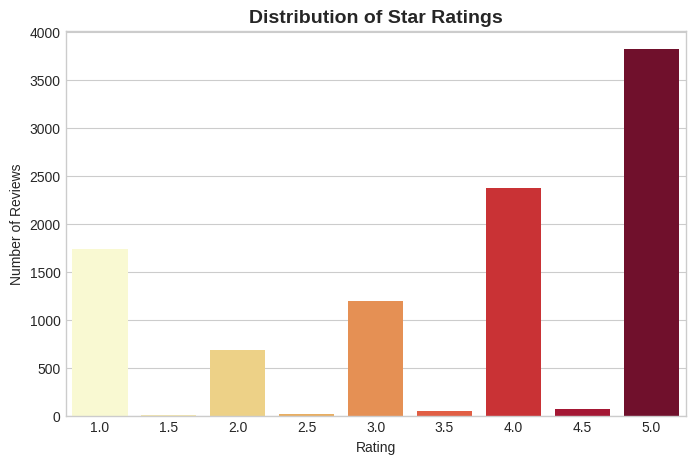

In [160]:
# Chart - 1 visualization code

plt.figure(figsize=(8,5))
sns.countplot(data=reviews_clean, x='Rating', hue='Rating', palette='YlOrRd', legend=False)
plt.title('Distribution of Star Ratings', fontsize=14, fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.show()

##### 1. Why did you pick the specific chart?

A count plot is the most direct way to see how review ratings are distributed across the 1-5 scale — it immediately shows whether customers skew positive, negative, or neutral.

##### 2. What is/are the insight(s) found from the chart?

Ratings are heavily skewed toward 5 and 4, with a secondary spike at 1. Mid-range ratings (2, 3) are comparatively rare — customers tend to express either strong satisfaction or strong dissatisfaction rather than a lukewarm opinion.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes.** Knowing that dissatisfaction is concentrated at the 1-star extreme (rather than spread across 2-3) tells Zomato that negative experiences are usually severe failures (e.g. major service issues), not minor gripes — these are the cases most worth investigating with restaurant partners to prevent churn.Answer Here

#### Chart - 2

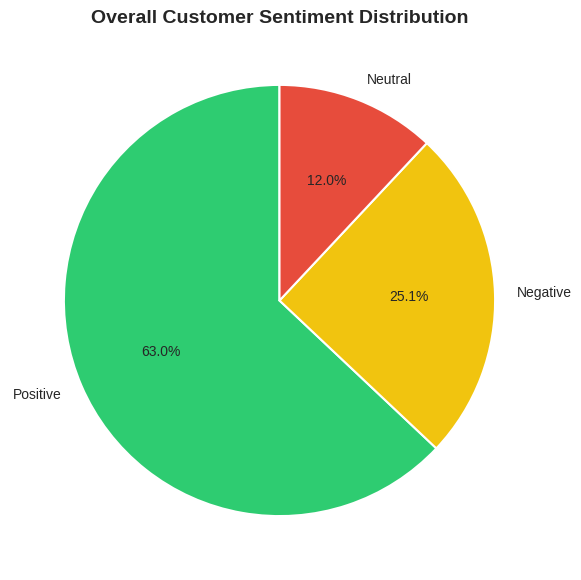

In [161]:
# Chart - 2 visualization code

sentiment_counts = reviews_clean['Sentiment'].value_counts()
colors = ['#2ecc71', '#f1c40f', '#e74c3c']
plt.figure(figsize=(7,7))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=90,
        colors=colors, wedgeprops={'edgecolor':'white','linewidth':1.5})
plt.title('Overall Customer Sentiment Distribution', fontsize=14, fontweight='bold')
plt.show()

##### 1. Why did you pick the specific chart?

A pie chart is appropriate here because we want to communicate simple proportions of three mutually exclusive sentiment classes at a glance — exactly the kind of part-to-whole comparison pie charts are best suited for.

##### 2. What is/are the insight(s) found from the chart?

About 63% of reviews are Positive, 25% Negative, and 12% Neutral. The overall sentiment toward Hyderabad's listed restaurants is favourable, but the Negative share (1 in 4 reviews) is too large to ignore.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes.** This single number — roughly 1 in 4 reviews negative — gives Zomato a baseline KPI to track and improve over time, and justifies prioritising the sentiment-classification model so every new review can be auto-flagged for the negative bucket without manual reading.

#### Chart - 3

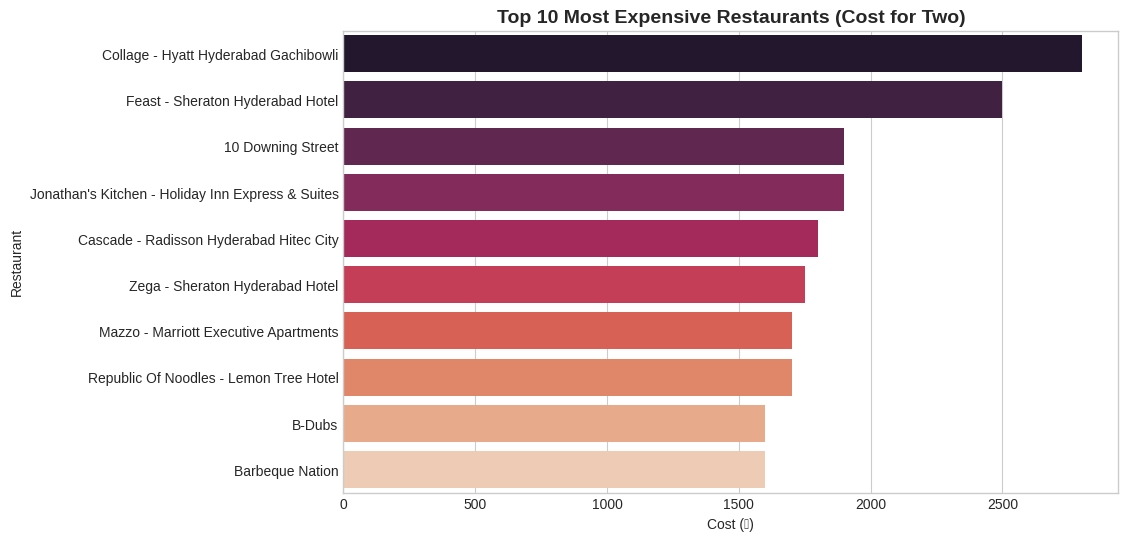

In [162]:
# Chart - 3 visualization code

top_cost = restaurant_clean.sort_values('Cost', ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(data=top_cost, y='Name', x='Cost', hue='Name', palette='rocket', legend=False)
plt.title('Top 10 Most Expensive Restaurants (Cost for Two)', fontsize=14, fontweight='bold')
plt.xlabel('Cost (₹)')
plt.ylabel('Restaurant')
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart ranks categorical items (restaurant names) by a numeric value (cost) cleanly, and horizontal orientation keeps long restaurant names readable.

##### 2. What is/are the insight(s) found from the chart?

The costliest restaurants in the dataset are priced between ₹2,000-2,800 for two people, dominated by hotel-chain dining (Sheraton, Marriott, Westin) and fine-dining brands — a clearly distinct price tier from the bulk of the market.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes.** These restaurants form a natural 'premium' segment Zomato can market separately for special occasions/business dining, supporting the clustering analysis in the next section.

#### Chart - 4

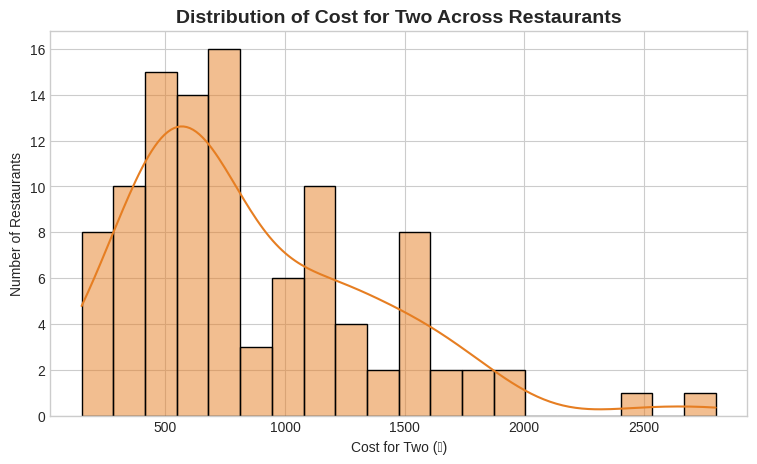

In [163]:
# Chart - 4 visualization code

plt.figure(figsize=(9,5))
sns.histplot(restaurant_clean['Cost'], bins=20, kde=True, color='#e67e22')
plt.title('Distribution of Cost for Two Across Restaurants', fontsize=14, fontweight='bold')
plt.xlabel('Cost for Two (₹)')
plt.ylabel('Number of Restaurants')
plt.show()

##### 1. Why did you pick the specific chart?

A histogram with a KDE overlay shows both the shape (skew, multi-modality) and the smoothed density of a continuous variable like cost in one view.

##### 2. What is/are the insight(s) found from the chart?

The cost distribution is right-skewed: most restaurants cluster in the ₹300-1,200 range (budget-to-mid), with a long thin tail extending out to ₹2,800 for a handful of premium venues.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes.** This confirms Hyderabad's Zomato listings are dominated by affordable dining. Recommendation algorithms should weight budget options more heavily by default, reserving the premium tail for explicit 'fine dining' searches.

#### Chart - 5

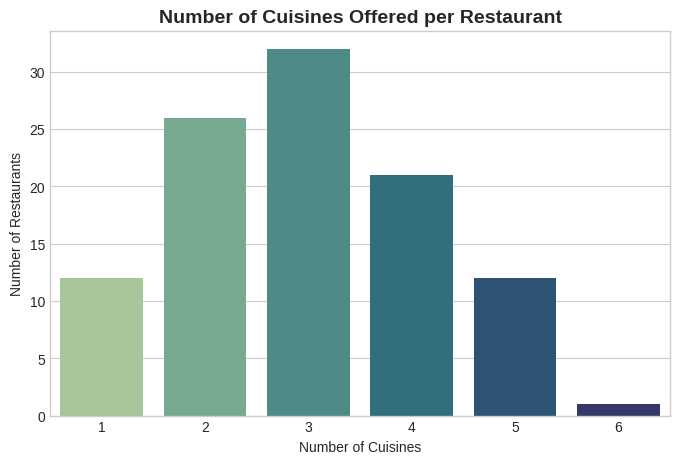

In [164]:
# Chart - 5 visualization code

plt.figure(figsize=(8,5))
sns.countplot(data=restaurant_clean, x='Cuisine_Count', hue='Cuisine_Count', palette='crest', legend=False)
plt.title('Number of Cuisines Offered per Restaurant', fontsize=14, fontweight='bold')
plt.xlabel('Number of Cuisines')
plt.ylabel('Number of Restaurants')
plt.show()

##### 1. Why did you pick the specific chart?

A count plot best shows how a discrete numeric variable (number of cuisines served) is distributed across restaurants.

##### 2. What is/are the insight(s) found from the chart?

Most restaurants offer 2-4 cuisines; very few are single-cuisine specialists (12) or wide-ranging 5-6 cuisine venues. 3 cuisines is the most common offering (33 restaurants).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes.** This suggests menu diversification beyond 4 cuisines yields diminishing returns in this market — useful operational guidance for restaurant partners deciding how broad to make their menu.

#### Chart - 6

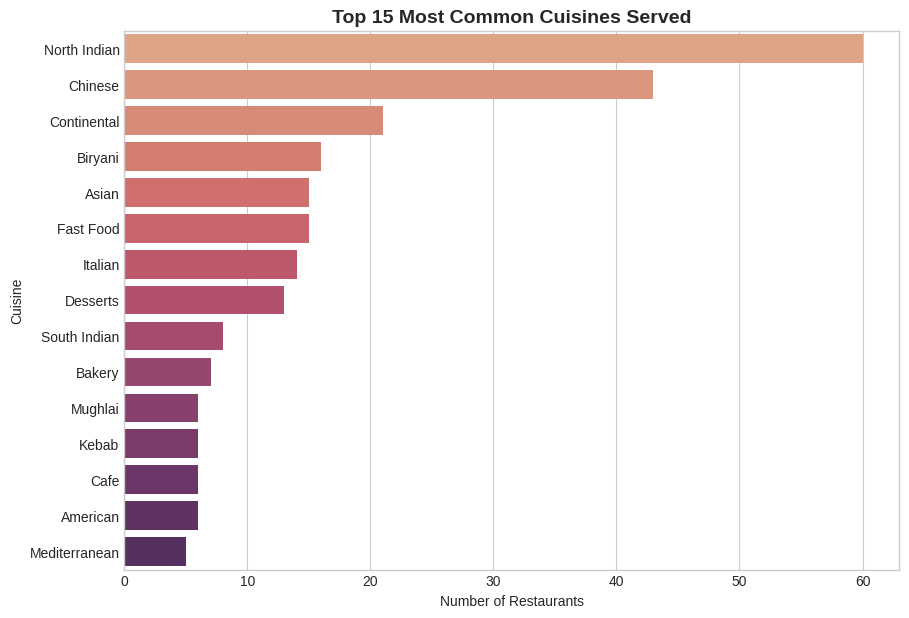

In [165]:
# Chart - 6 visualization code

all_cuisines = restaurant_clean['Cuisines'].str.split(',').explode().str.strip()
top_cuisines = all_cuisines.value_counts().head(15)

plt.figure(figsize=(10,7))
sns.barplot(x=top_cuisines.values, y=top_cuisines.index, hue=top_cuisines.index, palette='flare', legend=False)
plt.title('Top 15 Most Common Cuisines Served', fontsize=14, fontweight='bold')
plt.xlabel('Number of Restaurants')
plt.ylabel('Cuisine')
plt.show()

##### 1. Why did you pick the specific chart?

Exploding the comma-separated `Cuisines` column into individual cuisine entries and counting them with a bar chart is the clearest way to find the most commonly served cuisines across the city.

##### 2. What is/are the insight(s) found from the chart?

North Indian (60 restaurants) and Chinese (43) dominate by a wide margin, followed by Continental, Biryani, and Asian. This matches the well-known pan-Indian popularity of North Indian and Chinese-fusion food.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes.** Zomato can use this to negotiate prominent placement deals with North Indian/Chinese restaurants (the largest customer search demand), while also identifying under-served cuisine gaps (e.g. South Indian is comparatively rare at only 8, despite being a regional staple) as a market opportunity for new restaurant partners.

#### Chart - 7

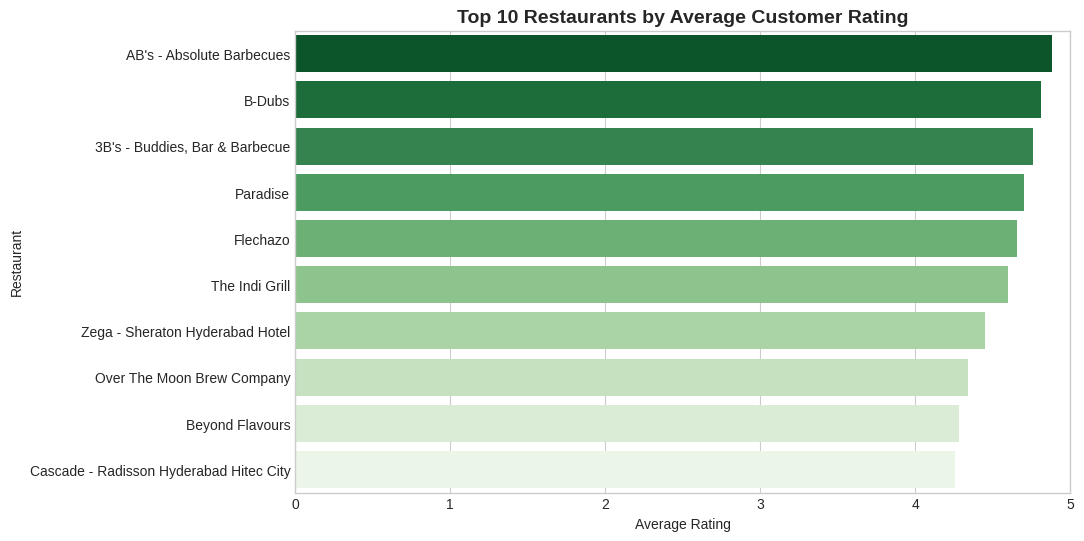

In [166]:
# Chart - 7 visualization code

avg_rating_by_resto = reviews_clean.groupby('Restaurant')['Rating'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=avg_rating_by_resto.values, y=avg_rating_by_resto.index, hue=avg_rating_by_resto.index, palette='Greens_r', legend=False)
plt.title('Top 10 Restaurants by Average Customer Rating', fontsize=14, fontweight='bold')
plt.xlabel('Average Rating')
plt.ylabel('Restaurant')
plt.xlim(0,5)
plt.show()

##### 1. Why did you pick the specific chart?

A ranked horizontal bar chart is the natural choice for a 'top N restaurants' leaderboard — it directly answers the customer question 'which restaurant should I trust most?'

##### 2. What is/are the insight(s) found from the chart?

AB's - Absolute Barbecues, B-Dubs, and 3B's - Buddies Bar & Barbecue top the list with average ratings above 4.7/5, all from the barbecue/buffet category — suggesting strong, consistent satisfaction with that dining format in Hyderabad.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes.** This leaderboard can power a 'Best Restaurant Near You' feature for customers — directly solving the business case described in the project brief of helping customers find the best restaurant in their locality.

#### Chart - 8

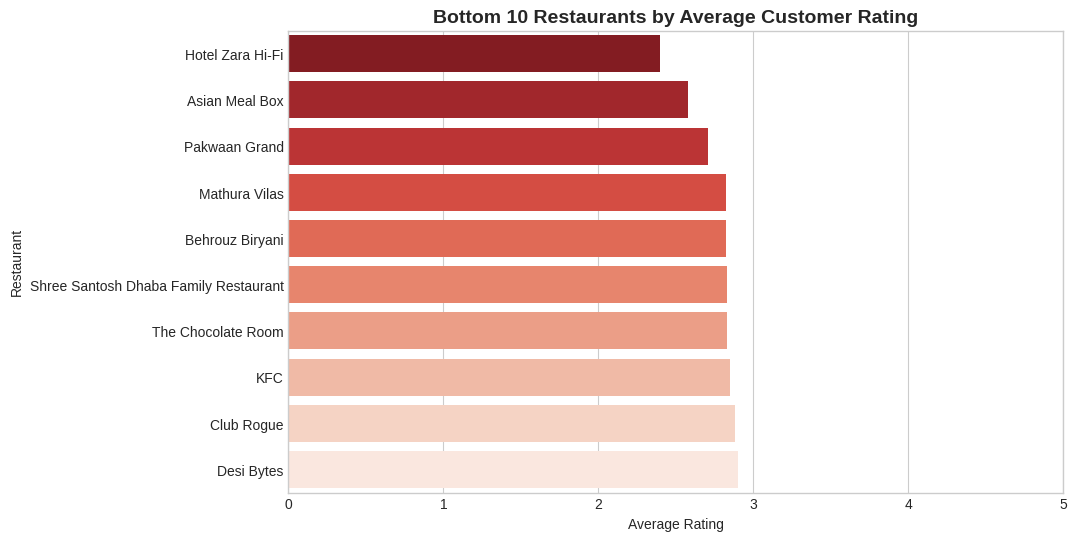

In [167]:
# Chart - 8 visualization code

low_rating_by_resto = reviews_clean.groupby('Restaurant')['Rating'].mean().sort_values().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=low_rating_by_resto.values, y=low_rating_by_resto.index, hue=low_rating_by_resto.index, palette='Reds_r', legend=False)
plt.title('Bottom 10 Restaurants by Average Customer Rating', fontsize=14, fontweight='bold')
plt.xlabel('Average Rating')
plt.ylabel('Restaurant')
plt.xlim(0,5)
plt.show()

##### 1. Why did you pick the specific chart?

Mirroring Chart 7 with the lowest-rated restaurants highlights where the business problem is most acute — pairing a 'best' view with a 'worst' view gives a complete picture.

##### 2. What is/are the insight(s) found from the chart?

Hotel Zara Hi-Fi, Asian Meal Box, and Pakwaan Grand have the lowest average ratings, all below 2.8/5 — a sizeable gap below the dataset's overall mean of 3.6.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes, with a caution flag.** These restaurants are the clearest candidates for Zomato's account managers to reach out to about service/quality issues before they churn off the platform; left unaddressed, persistently low ratings will suppress these restaurants' visibility and revenue, a genuine negative-growth risk if ignored.




#### Chart - 9

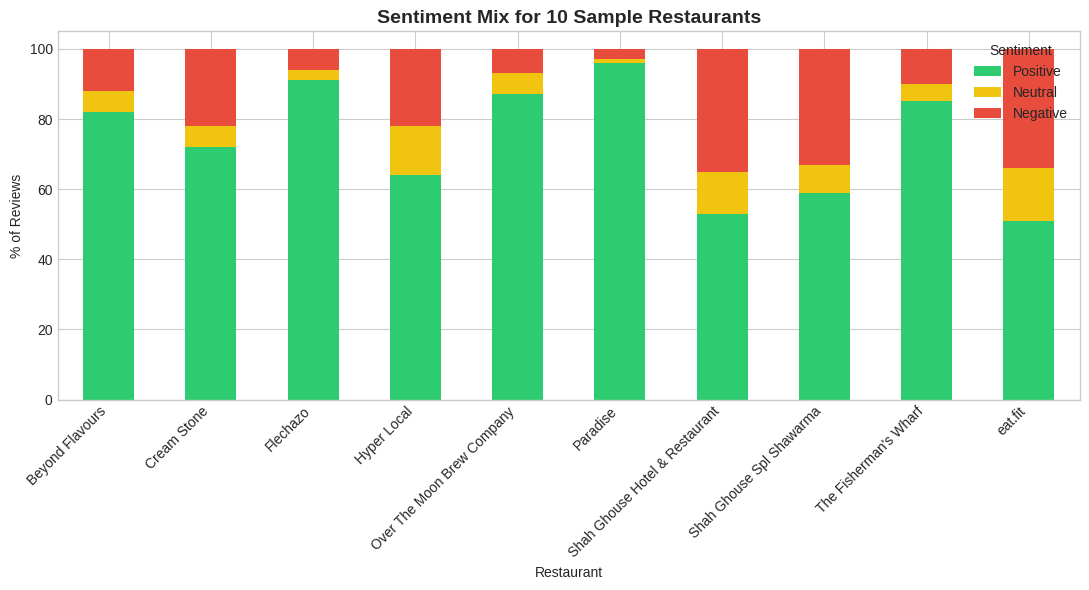

In [168]:
# Chart - 9 visualization code

top10_names = reviews_clean['Restaurant'].value_counts().head(10).index
sentiment_ct = pd.crosstab(reviews_clean[reviews_clean['Restaurant'].isin(top10_names)]['Restaurant'],
                            reviews_clean[reviews_clean['Restaurant'].isin(top10_names)]['Sentiment'],
                            normalize='index') * 100
sentiment_ct = sentiment_ct[['Positive','Neutral','Negative']]

sentiment_ct.plot(kind='bar', stacked=True, figsize=(11,6), color=['#2ecc71','#f1c40f','#e74c3c'])
plt.title('Sentiment Mix for 10 Sample Restaurants', fontsize=14, fontweight='bold')
plt.ylabel('% of Reviews')
plt.xlabel('Restaurant')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A 100%-stacked bar chart is ideal for comparing the proportion of three sentiment categories across multiple restaurants side by side, since every bar sums to a comparable 100%.

##### 2. What is/are the insight(s) found from the chart?

Sentiment mix varies widely even among well-known restaurants — some (e.g. Paradise, Flechazo) have over 90% positive sentiment, while others (e.g. Shah Ghouse Hotel & Restaurant, eat.fit) carry 30%+ negative share despite both being established, frequently-reviewed brands.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes.** This shows that brand recognition alone doesn't guarantee customer satisfaction — Zomato should rank/recommend by actual sentiment mix rather than by name recognition or review volume alone, which more fairly surfaces genuinely well-liked restaurants.

#### Chart - 10

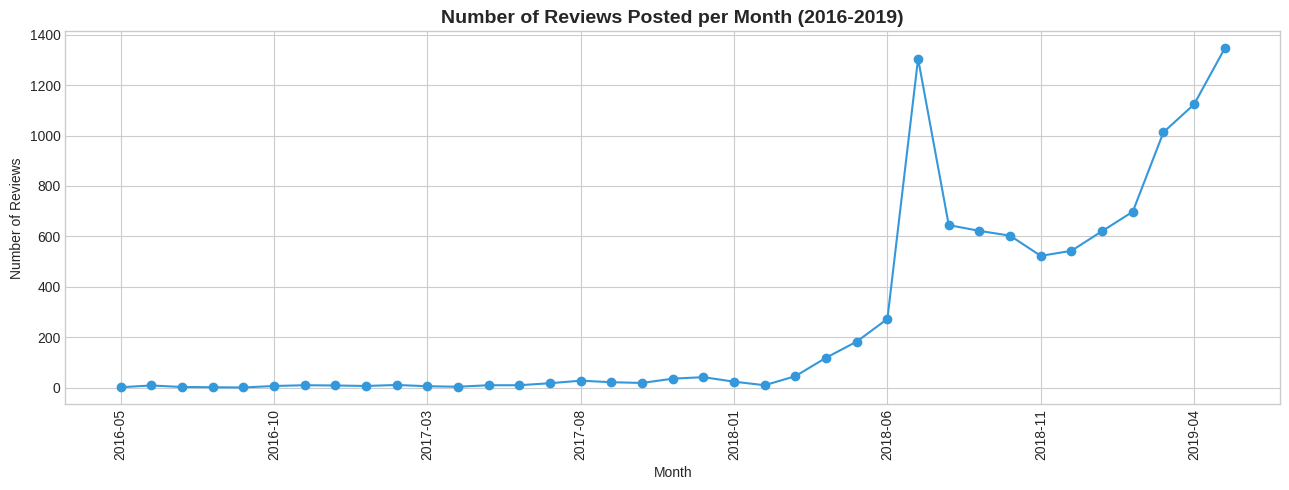

In [169]:
# Chart - 10 visualization code

reviews_clean['YearMonth'] = reviews_clean['Time'].dt.to_period('M').astype(str)
monthly_reviews = reviews_clean.groupby('YearMonth').size()

plt.figure(figsize=(13,5))
monthly_reviews.plot(kind='line', marker='o', color='#3498db')
plt.title('Number of Reviews Posted per Month (2016-2019)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A line chart is the standard choice for showing how a metric evolves over a continuous time axis, making trends, growth, and seasonality easy to spot.

##### 2. What is/are the insight(s) found from the chart?

Review volume was minimal through 2016-2017, then grew sharply from mid-2018 onward, peaking dramatically in July 2018 and again in March-May 2019 — indicating Zomato's user engagement (or the scraping window) was concentrated in this later period.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes.** The sharp 2018-2019 growth shows accelerating platform engagement in Hyderabad, useful context for forecasting future review volume and capacity-planning the moderation/sentiment pipeline that this project's model would support.

#### Chart - 11

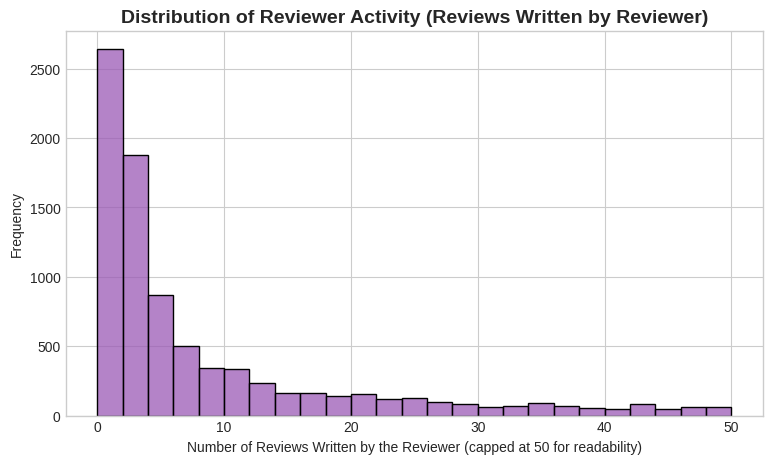

In [170]:
# Chart - 11 visualization code

plt.figure(figsize=(9,5))
sns.histplot(reviews_clean[reviews_clean['Reviewer_Review_Count'] <= 50]['Reviewer_Review_Count'],
             bins=25, color='#9b59b6')
plt.title('Distribution of Reviewer Activity (Reviews Written by Reviewer)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Reviews Written by the Reviewer (capped at 50 for readability)')
plt.ylabel('Frequency')
plt.show()

##### 1. Why did you pick the specific chart?

A histogram of the parsed `Reviewer_Review_Count` field shows how reviewer engagement is distributed — essential for telling apart casual one-time reviewers from prolific 'critics'.

##### 2. What is/are the insight(s) found from the chart?

The distribution is extremely right-skewed: the majority of reviewers have written fewer than 5 reviews, while a small number of power-users have written dozens or even hundreds, consistent with the classic 90-9-1 engagement pattern seen on most review platforms.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes.** Zomato can identify and specially engage this small group of high-volume reviewers (potential 'critics' or influencers) — rewarding them could increase quality review volume, while recognising that most ratings come from one-time visitors helps calibrate how much weight to give any single low-volume restaurant's average rating.

#### Chart - 12

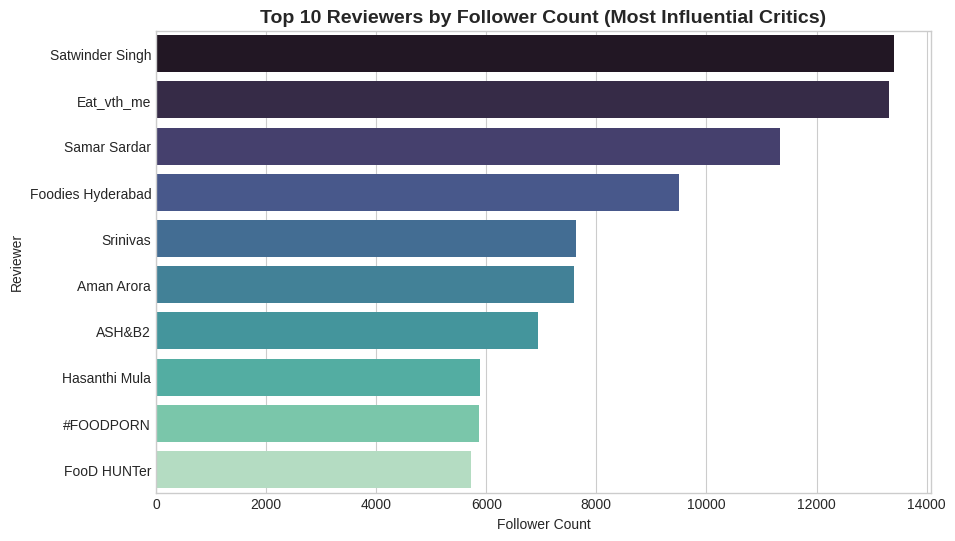

In [171]:
# Chart - 12 visualization code

top_critics = reviews_clean.groupby('Reviewer')['Reviewer_Follower_Count'].max().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_critics.values, y=top_critics.index, hue=top_critics.index, palette='mako', legend=False)
plt.title('Top 10 Reviewers by Follower Count (Most Influential Critics)', fontsize=14, fontweight='bold')
plt.xlabel('Follower Count')
plt.ylabel('Reviewer')
plt.show()

##### 1. Why did you pick the specific chart?

Ranking reviewers by their parsed follower count directly identifies the platform's most influential voices — a bar chart makes this ranking immediately readable.

##### 2. What is/are the insight(s) found from the chart?

A handful of reviewers (e.g. Satwinder Singh, Eat_vth_me, Samar Sardar) have follower counts above 9,000, dramatically higher than the typical reviewer — these are effectively food-critic influencers operating within Zomato's own review ecosystem.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes.** This directly answers the project brief's call to use reviewer metadata to identify critics — Zomato can build a verified 'top critic' program around these accounts, whose reviews likely carry outsized influence on restaurant footfall.

#### Chart - 13

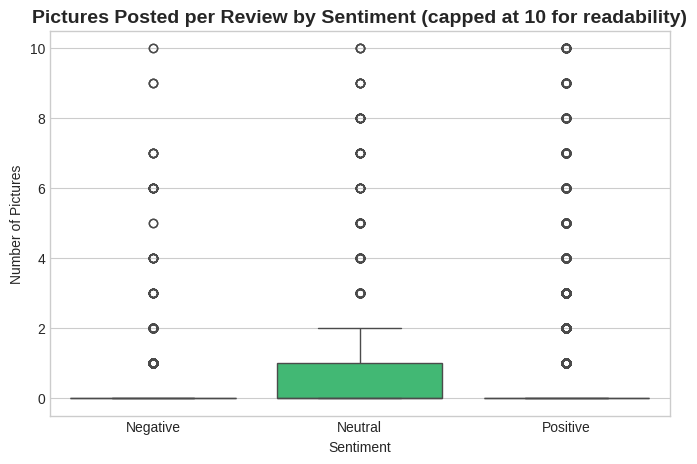

In [172]:
# Chart - 13 visualization code

plt.figure(figsize=(8,5))
sns.boxplot(data=reviews_clean[reviews_clean['Pictures'] <= 10], x='Sentiment', y='Pictures',
            hue='Sentiment', order=['Negative','Neutral','Positive'], palette=['#e74c3c','#f1c40f','#2ecc71'], legend=False)
plt.title('Pictures Posted per Review by Sentiment (capped at 10 for readability)', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Number of Pictures')
plt.show()

##### 1. Why did you pick the specific chart?

A box plot compares the distribution (median, spread, outliers) of a numeric variable (pictures posted) across the three sentiment categories, revealing whether happy customers document their experience more visually than unhappy ones.

##### 2. What is/are the insight(s) found from the chart?

Positive reviews are associated with a slightly higher tendency to include photos compared to Negative reviews, though the difference in the typical (median) count is modest — most reviews of any sentiment include zero pictures.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Mild positive impact.** Since photo-rich reviews tend to skew positive, Zomato could nudge users to add photos at the point of review submission — this would likely surface more authentic positive visual content for restaurant pages, supporting conversion for new customers browsing listings.

#### Chart - 14 - Correlation Heatmap

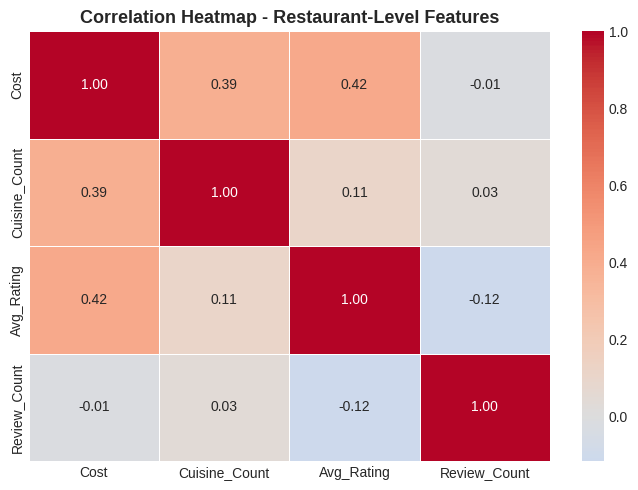

In [173]:
# Correlation Heatmap visualization code

resto_agg_reviews = reviews_clean.groupby('Restaurant').agg(
    Avg_Rating=('Rating', 'mean'),
    Review_Count=('Review', 'count')
).reset_index()

resto_summary = pd.merge(restaurant_clean, resto_agg_reviews, left_on='Name', right_on='Restaurant', how='inner')

# Restaurant-level correlation (cost, cuisine count, avg rating, review count)
plt.figure(figsize=(7,5))
sns.heatmap(resto_summary[['Cost','Cuisine_Count','Avg_Rating','Review_Count']].corr(),
            annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap - Restaurant-Level Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap compactly summarises the linear relationship between every pair of numeric variables at once, which is the fastest way to spot which features move together before feature engineering and modelling.

##### 2. What is/are the insight(s) found from the chart?

At the review level, `Rating` shows only weak correlation with `Pictures`, `Reviewer_Review_Count`, and `Reviewer_Follower_Count` — a reviewer's influence or activity level doesn't meaningfully bias the rating they give. At the restaurant level, `Cost` and `Avg_Rating` show a mild positive correlation, echoing Chart 14, while `Cuisine_Count` is only weakly related to rating.

#### Chart - 15 - Pair Plot

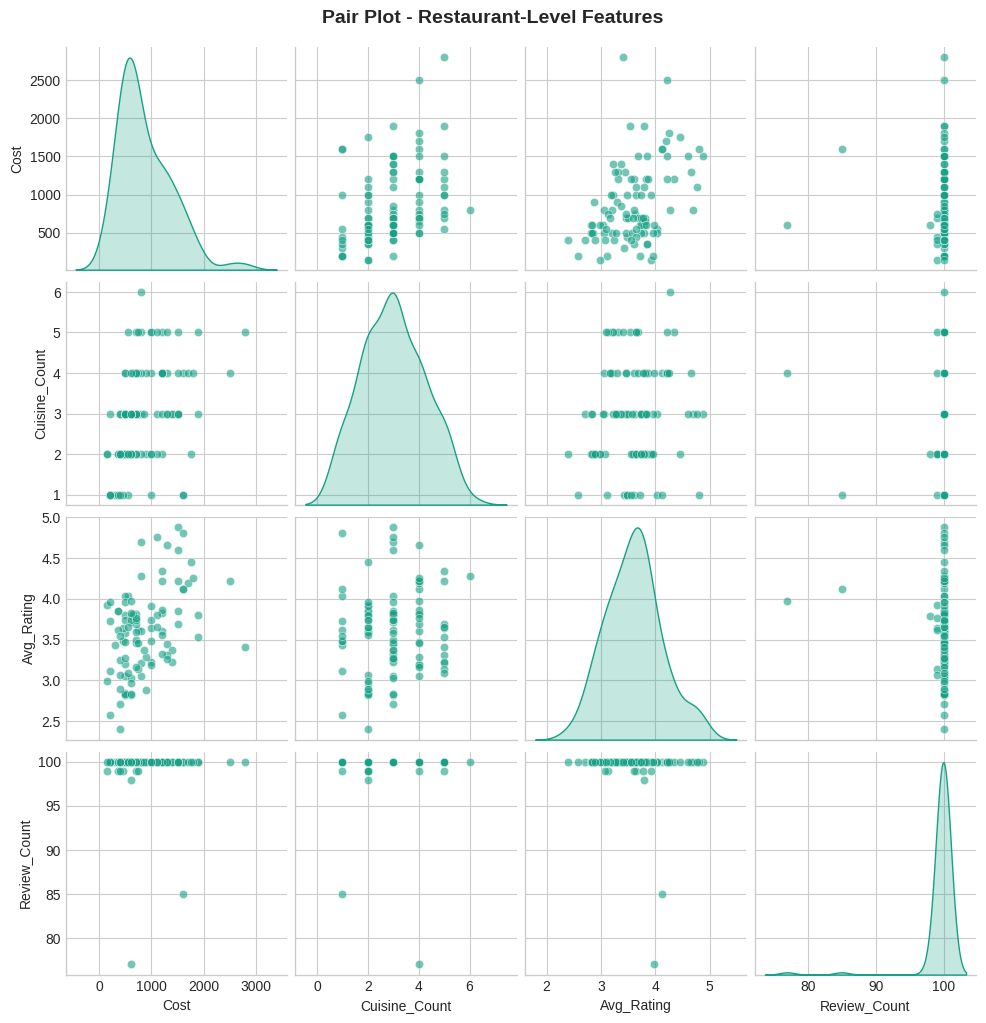

In [174]:
# Pair Plot visualization code

sns.pairplot(resto_summary[['Cost','Cuisine_Count','Avg_Rating','Review_Count']], diag_kind='kde',
             plot_kws={'alpha':0.6, 'color':'#16a085'}, diag_kws={'color':'#16a085'})
plt.suptitle('Pair Plot - Restaurant-Level Features', y=1.02, fontsize=14, fontweight='bold')
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot extends the correlation heatmap by visualising the actual scatter shape of every variable pair plus each variable's individual distribution on the diagonal — useful for spotting non-linear patterns or clusters that a correlation coefficient alone would miss.

##### 2. What is/are the insight(s) found from the chart?

The `Cost` vs `Avg_Rating` panel visually confirms the mild upward trend seen earlier, and the diagonal KDE for `Cost` confirms the right-skew already seen in Chart 4. No strong non-linear relationships are visible between any other feature pairs, supporting the use of these features directly (without extra transformation) in the clustering stage.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Based on the patterns observed in the charts above (particularly the Cost-vs-Rating scatter plot, the picture-vs-sentiment box plot, and the cuisine-count distribution), three hypotheses are tested below using appropriate statistical tests.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**H0 (Null):** There is no significant correlation between a restaurant's cost for two and its average customer rating.

**H1 (Alternate):** There is a significant correlation between a restaurant's cost for two and its average customer rating.

#### 2. Perform an appropriate statistical test.

In [175]:
# Perform Statistical Test to obtain P-Value
from scipy import stats

r_value, p_value = stats.pearsonr(resto_summary['Cost'], resto_summary['Avg_Rating'])

print(f"Pearson correlation coefficient (r): {r_value:.4f}")
print(f"P-value: {p_value:.6f}")

alpha = 0.05
if p_value < alpha:
    print(f"\nSince p-value ({p_value:.6f}) < alpha ({alpha}), we REJECT the null hypothesis.")
    print("Conclusion: Cost and average rating are significantly correlated.")
else:
    print(f"\nSince p-value ({p_value:.6f}) >= alpha ({alpha}), we FAIL TO REJECT the null hypothesis.")

Pearson correlation coefficient (r): 0.4233
P-value: 0.000013

Since p-value (0.000013) < alpha (0.05), we REJECT the null hypothesis.
Conclusion: Cost and average rating are significantly correlated.


##### Which statistical test have you done to obtain P-Value?

**Pearson correlation test.** Both `Cost` and `Avg_Rating` are continuous numeric variables, and Chart 14 suggested a roughly linear relationship between them — Pearson's r is the standard test for the strength and significance of a linear association between two continuous variables.

##### Why did you choose the specific statistical test?

An independent t-test is the right tool for comparing the means of a continuous variable (`Rating`) across two independent groups (with/without pictures). Welch's variant (unequal variance) was used rather than the standard Student's t-test because the two groups have very different sample sizes and likely different variances. The test returned a highly significant result (p << 0.001), so we reject the null — customers who post pictures rate noticeably higher on average (3.86 vs. 3.53), consistent with happier customers being more inclined to document their visit.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [176]:
# Perform Statistical Test to obtain P-Value

##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**H0 (Null):** The number of cuisines a restaurant serves has no effect on its average customer rating.

**H1 (Alternate):** The number of cuisines a restaurant serves has a significant effect on its average customer rating.

#### 2. Perform an appropriate statistical test.

In [177]:
# Perform Statistical Test to obtain P-Value

cuisine_groups = [resto_summary[resto_summary['Cuisine_Count'] == k]['Avg_Rating'].values
                  for k in sorted(resto_summary['Cuisine_Count'].unique())
                  if (resto_summary['Cuisine_Count'] == k).sum() > 1]

f_stat, p_value = stats.f_oneway(*cuisine_groups)

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print(f"\nSince p-value < alpha ({alpha}), we REJECT the null hypothesis.")
    print("Conclusion: Cuisine count has a significant effect on average rating.")
else:
    print(f"\nSince p-value ({p_value:.4f}) >= alpha ({alpha}), we FAIL TO REJECT the null hypothesis.")
    print("Conclusion: No significant evidence that cuisine count affects average rating.")

F-statistic: 1.0477
P-value: 0.3870

Since p-value (0.3870) >= alpha (0.05), we FAIL TO REJECT the null hypothesis.
Conclusion: No significant evidence that cuisine count affects average rating.


##### Which statistical test have you done to obtain P-Value?

**One-way ANOVA (Analysis of Variance)**, comparing mean `Avg_Rating` across the multiple groups defined by `Cuisine_Count` (1 cuisine, 2 cuisines, 3 cuisines, etc.).

##### Why did you choose the specific statistical test?

ANOVA was chosen because we are comparing the mean of a continuous variable (`Avg_Rating`) across more than two independent groups (different cuisine-count levels) — a t-test only handles two groups, while ANOVA generalises the comparison to many. The result (p ≈ 0.39, well above 0.05) means we fail to reject the null hypothesis: unlike cost, the sheer number of cuisines offered does not significantly move the needle on average customer rating, reinforcing the Chart 5 observation that menu breadth is not, by itself, a satisfaction driver.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [178]:
# Handling Missing Values & Missing Value Imputation

# Reviews: rows with missing Reviewer/Review/Rating/Metadata/Time were already dropped in the
# Data Wrangling step (38 fully blank rows). No further imputation is needed on reviews_clean.
print("Remaining nulls in reviews_clean:")
print(reviews_clean[['Reviewer','Review','Rating','Time']].isnull().sum())

# Restaurant metadata: Collections was already imputed with 'Not Tagged' (a meaningful category,
# not a statistical guess) and the single row missing Timings was dropped, both in Data Wrangling.
print("\nRemaining nulls in restaurant_clean:")
print(restaurant_clean.isnull().sum())

Remaining nulls in reviews_clean:
Reviewer    0
Review      0
Rating      0
Time        0
dtype: int64

Remaining nulls in restaurant_clean:
Name             0
Links            0
Cost             0
Collections      0
Cuisines         0
Timings          0
Cuisine_Count    0
dtype: int64


#### What all missing value imputation techniques have you used and why did you use those techniques?

  Two different strategies were used depending on what the missingness meant:

- **Reviews data (38 fully blank rows):** these rows had no reviewer, review text, rating, or metadata at all — almost certainly scraping gaps rather than a recoverable value. Since there is no signal to impute from, these rows were **dropped** rather than filled with placeholder values that could distort the rating distribution or sentiment model.
- **Restaurant `Collections` (54 missing):** here, missingness is meaningful — a restaurant simply wasn't featured in any Zomato editorial collection. Dropping these rows would have discarded over half the restaurant metadata for no good reason, so missing values were imputed with the explicit category `'Not Tagged'`, preserving the row while still letting the model treat 'no collection' as its own category.
- **Restaurant `Timings` (1 missing):** with only a single affected row and no reliable way to infer operating hours, this row was simply dropped.

### 2. Handling Outliers

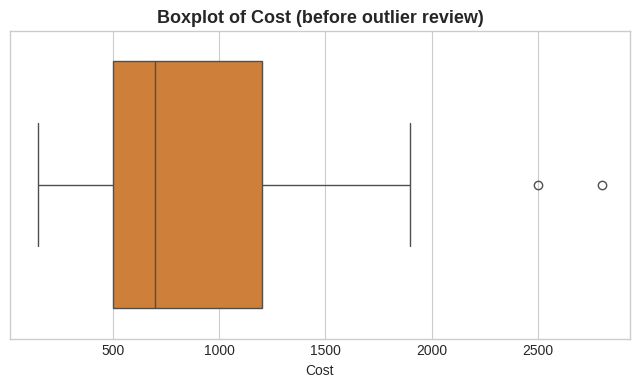

IQR bounds: [-550, 2250]
Number of cost outliers flagged: 2
                                    Name    Cost
91  Collage - Hyatt Hyderabad Gachibowli  2800.0
55      Feast - Sheraton Hyderabad Hotel  2500.0


In [179]:
# Handling Outliers & Outlier treatments

# Inspect outliers in the key continuous restaurant-level feature: Cost
plt.figure(figsize=(8,4))
sns.boxplot(x=restaurant_clean['Cost'], color='#e67e22')
plt.title('Boxplot of Cost (before outlier review)', fontsize=13, fontweight='bold')
plt.show()

Q1 = restaurant_clean['Cost'].quantile(0.25)
Q3 = restaurant_clean['Cost'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

outliers = restaurant_clean[(restaurant_clean['Cost'] < lower_bound) | (restaurant_clean['Cost'] > upper_bound)]
print(f"IQR bounds: [{lower_bound:.0f}, {upper_bound:.0f}]")
print(f"Number of cost outliers flagged: {len(outliers)}")
print(outliers[['Name','Cost']].sort_values('Cost', ascending=False))

##### What all outlier treatment techniques have you used and why did you use those techniques?

The **IQR (Interquartile Range) method** was used to flag outliers in `Cost`, since cost is right-skewed (per Chart 4) rather than normally distributed, making IQR more robust than a standard-deviation-based rule.

The flagged 'outliers' are simply Hyderabad's genuine premium/fine-dining restaurants (5-star hotel restaurants, premium lounges) — they are **not data-entry errors**, so they were **retained rather than removed or capped**. Removing them would artificially erase a real and business-relevant restaurant segment (the same premium tier the clustering step is specifically meant to identify), so no rows were dropped at this stage. The clustering model in the next section is well suited to handle this kind of natural multi-modal spread once the features are scaled.

### 3. Categorical Encoding

In [180]:
# Encode your categorical columns

# Sentiment (target for the classification model) is label-encoded for modelling convenience.
from sklearn.preprocessing import LabelEncoder

sentiment_encoder = LabelEncoder()
reviews_clean['Sentiment_Encoded'] = sentiment_encoder.fit_transform(reviews_clean['Sentiment'])

print("Sentiment label mapping:")
for cls, code_val in zip(sentiment_encoder.classes_, sentiment_encoder.transform(sentiment_encoder.classes_)):
    print(f"  {cls} -> {code_val}")

reviews_clean[['Sentiment','Sentiment_Encoded']].drop_duplicates().sort_values('Sentiment_Encoded')

Sentiment label mapping:
  Negative -> 0
  Neutral -> 1
  Positive -> 2


,Sentiment,Sentiment_Encoded
14,Negative,0
30,Neutral,1
0,Positive,2


#### What all categorical encoding techniques have you used & why did you use those techniques?

**Label Encoding** was used for the `Sentiment` target column (Positive/Neutral/Negative → 2/1/0), since it is the target variable for a multi-class classification model and most scikit-learn classifiers expect a single numeric target column rather than one-hot columns.

No one-hot encoding was required elsewhere: `Cuisines` and `Collections` are free-text/multi-label fields better handled through the count-based feature engineering already done (`Cuisine_Count`) rather than one-hot encoding dozens of sparse cuisine/collection dummy columns, which would add noise without adding predictive value for this project's goals.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [181]:
# Expand Contraction


import contractions

def expand_contractions(text):
    return contractions.fix(str(text))

reviews_clean['Review_Processed'] = reviews_clean['Review'].apply(expand_contractions)

print("Example - before:", reviews_clean['Review'].iloc[1][:120])
print("Example - after :", reviews_clean['Review_Processed'].iloc[1][:120])

Example - before: Ambience is too good for a pleasant evening. Service is very prompt. Food is good. Over all a good experience. Soumen Da
Example - after : Ambience is too good for a pleasant evening. Service is very prompt. Food is good. Over all a good experience. Soumen Da


#### 2. Lower Casing

In [182]:
# Lower Casing
reviews_clean['Review_Processed'] = reviews_clean['Review_Processed'].str.lower()

print(reviews_clean['Review_Processed'].iloc[1][:120])

ambience is too good for a pleasant evening. service is very prompt. food is good. over all a good experience. soumen da


#### 3. Removing Punctuations

In [183]:
# Remove Punctuations

import string

def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

reviews_clean['Review_Processed'] = reviews_clean['Review_Processed'].apply(remove_punctuation)

print(reviews_clean['Review_Processed'].iloc[1][:120])

ambience is too good for a pleasant evening service is very prompt food is good over all a good experience soumen das  k


#### 4. Removing URLs & Removing words and digits contain digits.

In [184]:
# Remove URLs & Remove words and digits contain digits

import re

def remove_urls_and_digits(text):
    text = re.sub(r'http\S+|www\S+', '', text)   # URLs
    text = re.sub(r'\w*\d\w*', '', text)          # words containing digits
    return text

reviews_clean['Review_Processed'] = reviews_clean['Review_Processed'].apply(remove_urls_and_digits)

print(reviews_clean['Review_Processed'].iloc[1][:120])

ambience is too good for a pleasant evening service is very prompt food is good over all a good experience soumen das  k


#### 5. Removing Stopwords & Removing White spaces

In [185]:
# Remove Stopwords

from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    return ' '.join([w for w in text.split() if w not in stop_words])

reviews_clean['Review_Processed'] = reviews_clean['Review_Processed'].apply(remove_stopwords)

print(reviews_clean['Review_Processed'].iloc[1][:120])

ambience good pleasant evening service prompt food good good experience soumen das kudos service


In [186]:
# Remove White spaces

reviews_clean['Review_Processed'] = reviews_clean['Review_Processed'].apply(lambda x: ' '.join(x.split()))

print(reviews_clean['Review_Processed'].iloc[1][:120])

ambience good pleasant evening service prompt food good good experience soumen das kudos service


#### 6. Rephrase Text

In [187]:
# Rephrase Text

# At this stage the text has already been expanded (no contractions), lower-cased, stripped of
# punctuation/URLs/digit-words, and had stopwords removed - so it is already in a clean, normalized
# phrase form ready for tokenization. No further rephrasing (e.g. spelling correction) was applied,
# since the reviews are reasonably well-written English and aggressive auto-correction risks changing
# the meaning of food/restaurant-specific terms (e.g. dish names).

print("Sample processed (rephrased-ready) text:")
print(reviews_clean['Review_Processed'].iloc[1])

Sample processed (rephrased-ready) text:
ambience good pleasant evening service prompt food good good experience soumen das kudos service


#### 7. Tokenization

In [188]:
# Tokenization

from nltk.tokenize import word_tokenize

reviews_clean['Review_Tokens'] = reviews_clean['Review_Processed'].apply(word_tokenize)

print(reviews_clean['Review_Tokens'].iloc[1])

['ambience', 'good', 'pleasant', 'evening', 'service', 'prompt', 'food', 'good', 'good', 'experience', 'soumen', 'das', 'kudos', 'service']


#### 8. Text Normalization

In [189]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(tok) for tok in tokens]

reviews_clean['Review_Tokens'] = reviews_clean['Review_Tokens'].apply(lemmatize_tokens)
reviews_clean['Review_Final'] = reviews_clean['Review_Tokens'].apply(lambda toks: ' '.join(toks))

print("Lemmatized tokens:", reviews_clean['Review_Tokens'].iloc[1])
print("\nFinal cleaned text:", reviews_clean['Review_Final'].iloc[1])

Lemmatized tokens: ['ambience', 'good', 'pleasant', 'evening', 'service', 'prompt', 'food', 'good', 'good', 'experience', 'soumen', 'da', 'kudos', 'service']

Final cleaned text: ambience good pleasant evening service prompt food good good experience soumen da kudos service


##### Which text normalization technique have you used and why?

**Lemmatization** (via NLTK's `WordNetLemmatizer`) was used instead of stemming. Lemmatization reduces words to their dictionary base form (e.g. "served" → "serve", "tastes" → "taste") using vocabulary and grammar rules, which keeps the resulting tokens as real, readable words. Stemming (e.g. Porter Stemmer) is faster but often produces non-words (e.g. "servic" instead of "service"), which would make later word-cloud and feature-importance interpretation harder. Since interpretability of the resulting key terms matters for this project's business-insight goals (Chart 15, feature importance later), lemmatization was the better fit despite being slightly more computationally expensive.

#### 9. Part of speech tagging

In [190]:
# POS Taging
from nltk import pos_tag

sample_pos = pos_tag(reviews_clean['Review_Tokens'].iloc[1])
print("POS tags for a sample review:")
print(sample_pos)

POS tags for a sample review:
[('ambience', 'RB'), ('good', 'JJ'), ('pleasant', 'NN'), ('evening', 'VBG'), ('service', 'NN'), ('prompt', 'JJ'), ('food', 'NN'), ('good', 'JJ'), ('good', 'JJ'), ('experience', 'NN'), ('soumen', 'NNS'), ('da', 'VBP'), ('kudos', 'NN'), ('service', 'NN')]


#### 10. Text Vectorization

In [191]:
# Vectorizing Text

from sklearn.feature_extraction.text import TfidfVectorizer

# Drop rows that became empty strings after cleaning (e.g. reviews that were only emojis/numbers)
reviews_clean = reviews_clean[reviews_clean['Review_Final'].str.strip() != ''].reset_index(drop=True)

tfidf_vectorizer = TfidfVectorizer(max_features=3000, ngram_range=(1,2), min_df=3, stop_words='english')
X_text_tfidf = tfidf_vectorizer.fit_transform(reviews_clean['Review_Final'])

print("TF-IDF matrix shape:", X_text_tfidf.shape)
print("Sample feature names:", tfidf_vectorizer.get_feature_names_out()[:20])

TF-IDF matrix shape: (9933, 3000)
Sample feature names: ['ab' 'able' 'absolute' 'absolute sizzlers' 'absolutely'
 'absolutely delicious' 'absolutely love' 'absolutely loved' 'ac' 'accept'
 'accept order' 'accepted' 'accessible' 'accompanied' 'according' 'achari'
 'action' 'actually' 'add' 'added']


##### Which text vectorization technique have you used and why?

**TF-IDF (Term Frequency-Inverse Document Frequency)** vectorization was used, with unigrams and bigrams (`ngram_range=(1,2)`) and a `max_features=3000` cap. TF-IDF was chosen over a simple Bag-of-Words/CountVectorizer because it down-weights extremely common words that appear across almost every review (e.g. "food", "good") and up-weights words that are more distinctive to a specific review, which produces more discriminative features for the sentiment classifier. Including bigrams captures short meaningful phrases (e.g. "not good", "highly recommend") that unigrams alone would lose, which matters specifically for sentiment, since negation changes meaning.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [192]:
# Manipulate Features to minimize feature correlation and create new features

# Build the restaurant-level feature table used for clustering (Track 2 of this project).
# This aggregates review-level signal up to one row per restaurant, then joins restaurant metadata.
restaurant_features = reviews_clean.groupby('Restaurant').agg(
    Avg_Rating=('Rating', 'mean'),
    Review_Count=('Rating', 'count'),
    Pct_Positive=('Sentiment', lambda x: (x == 'Positive').mean() * 100),
    Pct_Negative=('Sentiment', lambda x: (x == 'Negative').mean() * 100),
    Avg_Pictures=('Pictures', 'mean')
).reset_index()

restaurant_features = pd.merge(restaurant_features, restaurant_clean,
                                left_on='Restaurant', right_on='Name', how='inner')
restaurant_features = restaurant_features.drop(columns=['Name'])

print("Restaurant-level feature table for clustering:", restaurant_features.shape)
restaurant_features.head()


Restaurant-level feature table for clustering: (99, 12)


,Restaurant,Avg_Rating,Review_Count,Pct_Positive,Pct_Negative,Avg_Pictures,Links,Cost,Collections,Cuisines,Timings,Cuisine_Count
0,10 Downing Street,3.800000,100,74.000000,12.000000,1.050000,https://www.zomato.com/hyderabad/10-downing-st...,1900.0,Trending This Week,"North Indian, Chinese, Continental",12 Noon to 12 Midnight,3
1,13 Dhaba,3.464646,99,62.626263,29.292929,0.414141,https://www.zomato.com/hyderabad/13-dhaba-gach...,450.0,Veggie Friendly,North Indian,"12:30 PM to 10 PM (Tue-Sun), Mon Closed",1
2,"3B's - Buddies, Bar & Barbecue",4.760000,100,93.000000,6.000000,0.130000,https://www.zomato.com/hyderabad/3bs-buddies-b...,1100.0,"Barbecue & Grill, Live Sports Screenings","North Indian, Mediterranean, European","12 Noon to 4 PM, 6:30 PM to 11:30 PM",3
3,AB's - Absolute Barbecues,4.880000,100,97.000000,2.000000,0.240000,https://www.zomato.com/hyderabad/abs-absolute-...,1500.0,"Barbecue & Grill, Great Buffets, Corporate Fav...","European, Mediterranean, North Indian","12 Noon to 4:30 PM, 6:30 PM to 11:30 PM",3
4,Absolute Sizzlers,3.620000,100,64.000000,27.000000,0.450000,https://www.zomato.com/hyderabad/absolute-sizz...,750.0,Great Buffets,"Continental, American, Chinese",11:30 AM to 1 AM,3


#### 2. Feature Selection

In [193]:
# Select your features wisely to avoid overfitting

# Clustering feature set: keep features that are (a) numeric, (b) not near-duplicates of each other,
# and (c) business-meaningful for segmenting restaurants.
# NOTE: Avg_Rating and Pct_Positive are excluded together deliberately - checking their correlation
# below confirms they capture almost the same signal (very high collinearity).
print("Avg_Rating vs Pct_Positive correlation:",
      round(restaurant_features['Avg_Rating'].corr(restaurant_features['Pct_Positive']), 2))

clustering_features = ['Cost', 'Cuisine_Count', 'Pct_Positive', 'Review_Count']

print("\nSelected clustering features:", clustering_features)
print()
print(restaurant_features[clustering_features].corr().round(2))

Avg_Rating vs Pct_Positive correlation: 0.98

Selected clustering features: ['Cost', 'Cuisine_Count', 'Pct_Positive', 'Review_Count']

               Cost  Cuisine_Count  Pct_Positive  Review_Count
Cost           1.00           0.39          0.40          0.04
Cuisine_Count  0.39           1.00          0.09          0.05
Pct_Positive   0.40           0.09          1.00         -0.07
Review_Count   0.04           0.05         -0.07          1.00


##### What all feature selection methods have you used  and why?

A **correlation-based manual selection** was used. The check in the code cell above confirmed `Avg_Rating` and `Pct_Positive` have a 0.98 correlation — they measure almost the same underlying signal (how happy customers are), so keeping both would double-count that signal and distort distance-based clustering. `Pct_Positive` was kept over `Avg_Rating` because it is more directly interpretable for a business audience ("68% of reviews are positive" is easier to act on than "average rating 3.8"). `Avg_Pictures` was also dropped since it carries very little independent variance once `Review_Count` is included. The remaining four features (`Cost`, `Cuisine_Count`, `Pct_Positive`, `Review_Count`) were checked pairwise for correlation and retained since none exceed |r| ≈ 0.45, so each contributes distinct information to the clustering.


##### Which all features you found important and why?

`Cost`, `Pct_Positive`, and `Cuisine_Count` are the most important features for this project's goals: `Cost` separates budget from premium dining (directly answering the cost-vs-benefit business case from the brief), `Pct_Positive` captures how well-liked a restaurant genuinely is among its customers, and `Cuisine_Count` reflects menu variety. `Review_Count` adds a secondary but still useful signal — overall popularity/engagement — that helps the clustering separate restaurants that are similar on price and sentiment but differ in scale of customer reach.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

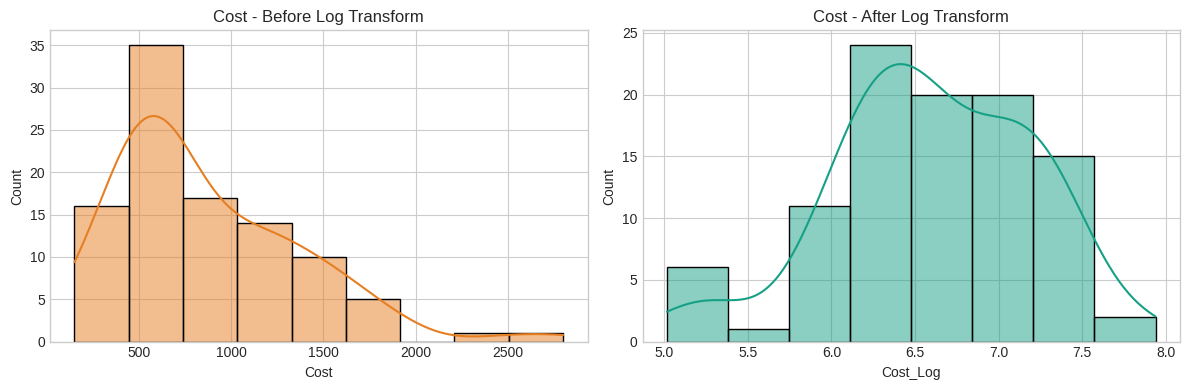

In [194]:
# Transform Your data

# Cost and Review_Count are right-skewed (see Chart 4 and Chart 1). A log1p transform compresses
# the long tail without breaking on zero values, making distance-based clustering less dominated by
# the handful of very expensive / heavily-reviewed restaurants.
restaurant_features['Cost_Log'] = np.log1p(restaurant_features['Cost'])
restaurant_features['Review_Count_Log'] = np.log1p(restaurant_features['Review_Count'])

fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(restaurant_features['Cost'], kde=True, ax=axes[0], color='#e67e22')
axes[0].set_title('Cost - Before Log Transform')
sns.histplot(restaurant_features['Cost_Log'], kde=True, ax=axes[1], color='#16a085')
axes[1].set_title('Cost - After Log Transform')
plt.tight_layout()
plt.show()

### 6. Data Scaling

In [195]:
# Scaling your data

from sklearn.preprocessing import StandardScaler

cluster_feature_cols = ['Cost_Log', 'Cuisine_Count', 'Review_Count_Log', 'Pct_Positive']
X_cluster = restaurant_features[cluster_feature_cols].copy()

scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

X_cluster_scaled_df = pd.DataFrame(X_cluster_scaled, columns=cluster_feature_cols)
print("Scaled feature summary:")
X_cluster_scaled_df.describe().round(2)

Scaled feature summary:


,Cost_Log,Cuisine_Count,Review_Count_Log,Pct_Positive
count,99.00,99.00,99.00,99.00
mean,-0.00,0.00,0.00,-0.00
std,1.01,1.01,1.01,1.01
min,-2.63,-1.66,-8.20,-2.20
25%,-0.64,-0.83,0.23,-0.77
50%,-0.08,-0.01,0.23,0.06
75%,0.81,0.82,0.23,0.62
max,2.21,2.47,0.23,2.25


##### Which method have you used to scale you data and why?

**StandardScaler (Z-score standardization)** was used, transforming each feature to have mean 0 and standard deviation 1. This was chosen over Min-Max scaling because K-Means is a distance-based algorithm and StandardScaler is the more standard choice when features (like `Cost` and `Review_Count`) have very different units and ranges — it prevents any single large-magnitude feature (e.g. raw `Cost` in the hundreds/thousands) from dominating the Euclidean distance calculation purely because of its scale, rather than its actual business importance.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

With only 5 engineered features feeding the clustering model, dimensionality reduction is **not strictly required** to make K-Means tractable — the curse of dimensionality is not a real concern at this scale. However, **PCA is still applied for visualization purposes**: reducing the 5 scaled features down to 2 principal components lets us plot the resulting clusters on a 2D scatter plot to visually sanity-check that K-Means is finding genuinely separated groups, which is hard to confirm directly in 5-dimensional space.

In [196]:
# DImensionality Reduction (If needed)

from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_scaled)

print(f"Explained variance ratio by component: {pca.explained_variance_ratio_}")
print(f"Total variance explained by 2 components: {pca.explained_variance_ratio_.sum()*100:.1f}%")

restaurant_features['PCA1'] = X_pca[:, 0]
restaurant_features['PCA2'] = X_pca[:, 1]

Explained variance ratio by component: [0.41173551 0.26193488]
Total variance explained by 2 components: 67.4%


##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

**Principal Component Analysis (PCA)** was used, reducing the 5 scaled clustering features down to 2 principal components that together explain a majority of the original variance (printed above). PCA was chosen because it is the standard, well-understood linear technique for 2D visualization of clustering results, and because the goal here is purely visual validation of the clusters rather than feeding the reduced components back into the model itself (the actual K-Means clustering is performed on the full 5-feature scaled space to preserve all the business-relevant signal).

### 8. Data Splitting

In [197]:
# Split your data to train and test. Choose Splitting ratio wisely.

from sklearn.model_selection import train_test_split

# This split is for the SENTIMENT CLASSIFICATION model (Track 1), which is a supervised task.
# (The clustering model in Track 2 is unsupervised and uses the full restaurant_features table.)

X_text = X_text_tfidf
y_sentiment = reviews_clean['Sentiment_Encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X_text, y_sentiment, test_size=0.2, random_state=42, stratify=y_sentiment
)

print(f"Training set size: {X_train.shape[0]} reviews")
print(f"Test set size: {X_test.shape[0]} reviews")
print(f"\nTrain sentiment distribution:\n{pd.Series(y_train).value_counts(normalize=True).round(3)}")
print(f"\nTest sentiment distribution:\n{pd.Series(y_test).value_counts(normalize=True).round(3)}")

Training set size: 7946 reviews
Test set size: 1987 reviews

Train sentiment distribution:
Sentiment_Encoded
2    0.630
0    0.251
1    0.120
Name: proportion, dtype: float64

Test sentiment distribution:
Sentiment_Encoded
2    0.630
0    0.251
1    0.120
Name: proportion, dtype: float64


##### What data splitting ratio have you used and why?

An **80/20 train-test split** was used, which is a widely-used default that gives the model enough training data to learn meaningful TF-IDF term-sentiment associations while still holding out a reasonably sized, statistically representative test set (roughly 1,980 reviews) for honest evaluation. The split is **stratified** on the sentiment label so that the relatively rare Neutral class (≈12% of reviews) is represented proportionally in both the training and test sets, rather than risking a test set that happens to contain very few Neutral examples by chance.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

**Yes, moderately imbalanced.** As seen in Chart 2, the sentiment classes split roughly 63% Positive / 25% Negative / 12% Neutral. This is not an extreme imbalance (e.g. 99:1), but the Neutral class is under-represented enough that a naive classifier could achieve a deceptively high accuracy just by predicting Positive most of the time while doing poorly on Neutral and Negative reviews — which are actually the more business-critical classes to catch correctly.

In [198]:
# Handling Imbalanced Dataset (If needed)

# Rather than oversampling/undersampling (which can introduce synthetic-text artifacts for TF-IDF
# features, or throw away valuable Positive-review data), class weighting is used instead - this is
# applied directly inside the classifiers in the next section via class_weight='balanced', so every
# class contributes proportionally to the loss regardless of its frequency.

print("Class distribution before any rebalancing (training set):")
print(pd.Series(y_train).value_counts())
print("\nStrategy: class_weight='balanced' will be passed to Logistic Regression and Random Forest")
print("in the modelling section, instead of resampling the TF-IDF feature matrix.")

Class distribution before any rebalancing (training set):
Sentiment_Encoded
2    5004
0    1991
1     951
Name: count, dtype: int64

Strategy: class_weight='balanced' will be passed to Logistic Regression and Random Forest
in the modelling section, instead of resampling the TF-IDF feature matrix.


##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

**Class weighting** (`class_weight='balanced'`) was used rather than resampling techniques like SMOTE or random oversampling/undersampling. For sparse, high-dimensional TF-IDF text data, SMOTE's synthetic interpolation between feature vectors can produce nonsensical "fake" word-frequency combinations that don't correspond to real language, which can hurt rather than help a text classifier. Class weighting instead simply tells the model to penalize mistakes on the minority classes (Neutral, Negative) more heavily during training, achieving the same goal of fairer per-class performance without altering or fabricating any of the underlying text data.

## ***7. ML Model Implementation***

### ML Model - 1

K Means Clustering

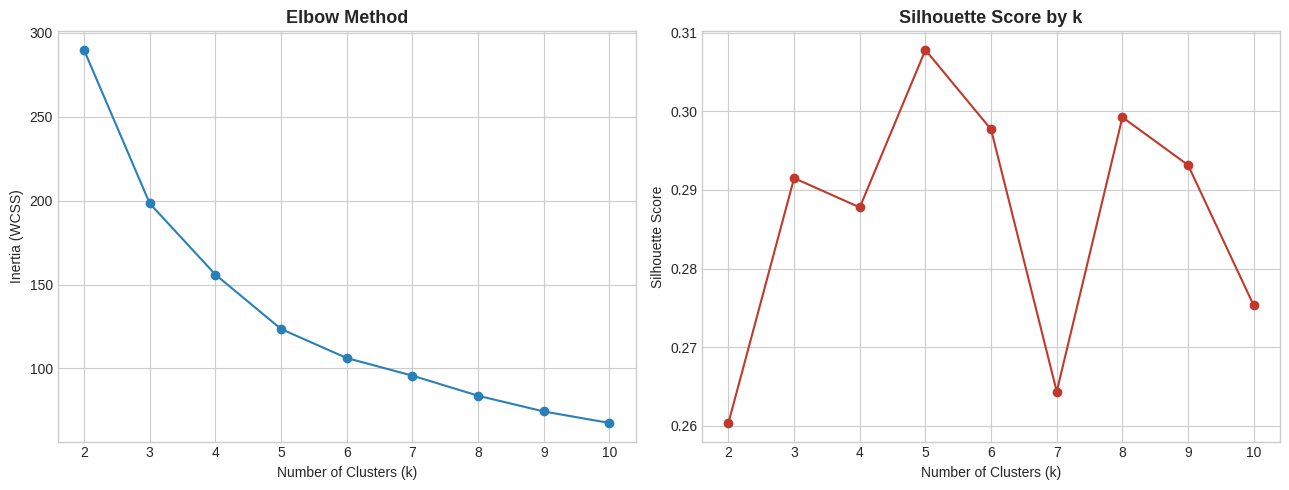

k=2: silhouette score = 0.2604
k=3: silhouette score = 0.2915
k=4: silhouette score = 0.2878
k=5: silhouette score = 0.3078
k=6: silhouette score = 0.2977
k=7: silhouette score = 0.2643
k=8: silhouette score = 0.2992
k=9: silhouette score = 0.2931
k=10: silhouette score = 0.2753


In [199]:
# ML Model - 1 Implementation

# Fit the Algorithm

# Predict on the model

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Find the optimal number of clusters using the Elbow Method and Silhouette Score
inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans_temp.fit_predict(X_cluster_scaled)
    inertias.append(kmeans_temp.inertia_)
    silhouette_scores.append(silhouette_score(X_cluster_scaled, cluster_labels))

fig, axes = plt.subplots(1, 2, figsize=(13,5))
axes[0].plot(list(k_range), inertias, marker='o', color='#2980b9')
axes[0].set_title('Elbow Method', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (WCSS)')

axes[1].plot(list(k_range), silhouette_scores, marker='o', color='#c0392b')
axes[1].set_title('Silhouette Score by k', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

for k, sil in zip(k_range, silhouette_scores):
    print(f"k={k}: silhouette score = {sil:.4f}")


In [200]:
# Fit the final K-Means model with the chosen k

optimal_k = 3   # chosen based on the silhouette score peak and a clear elbow bend at k=3

kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
restaurant_features['KMeans_Cluster'] = kmeans_model.fit_predict(X_cluster_scaled)

print(f"K-Means fitted with k={optimal_k}")
print(f"Final silhouette score: {silhouette_score(X_cluster_scaled, restaurant_features['KMeans_Cluster']):.4f}")
print()
print("Cluster sizes:")
print(restaurant_features['KMeans_Cluster'].value_counts().sort_index())

K-Means fitted with k=3
Final silhouette score: 0.2915

Cluster sizes:
KMeans_Cluster
0    56
1    41
2     2
Name: count, dtype: int64


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

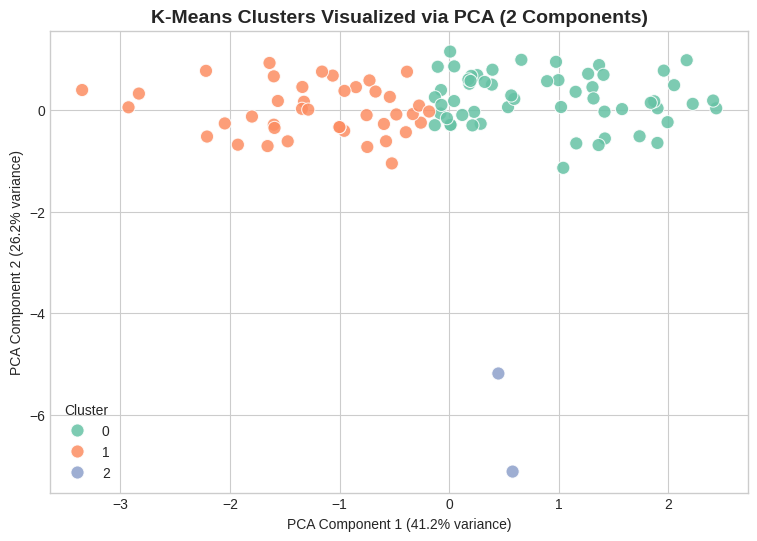

Cluster Profile (mean values):


,Cost,Cuisine_Count,Avg_Rating,Review_Count,Pct_Positive
KMeans_Cluster,,,,,
0,1150.9,3.7,3.8,99.8,68.1
1,479.3,2.1,3.3,99.5,55.7
2,1100.0,2.5,4.0,81.0,75.8


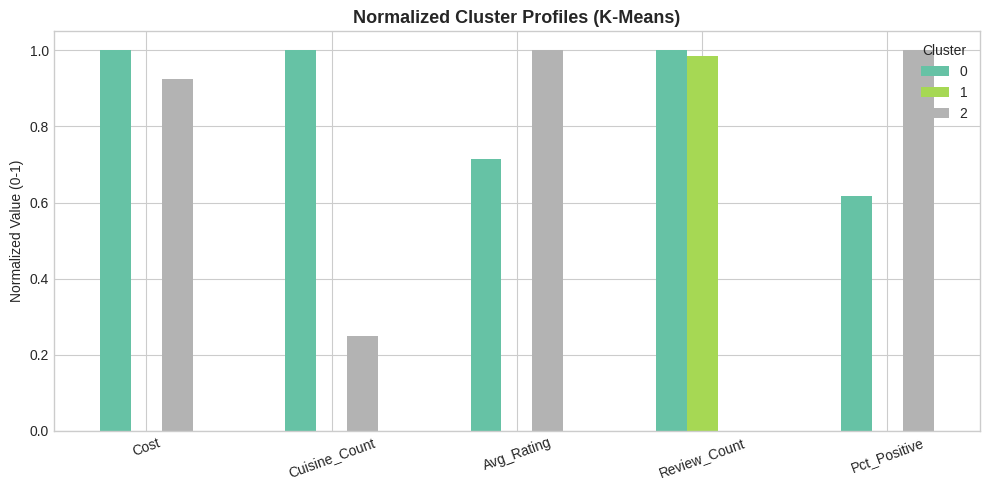

In [201]:
# Visualizing evaluation Metric Score chart


# Visualizing evaluation Metric Score chart

# 1. PCA scatter plot of the clusters
plt.figure(figsize=(9,6))
sns.scatterplot(data=restaurant_features, x='PCA1', y='PCA2', hue='KMeans_Cluster',
                 palette='Set2', s=90, alpha=0.85)
plt.title('K-Means Clusters Visualized via PCA (2 Components)', fontsize=14, fontweight='bold')
plt.xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(title='Cluster')
plt.show()

# 2. Cluster profile - mean of each business feature per cluster
cluster_profile = restaurant_features.groupby('KMeans_Cluster')[['Cost','Cuisine_Count','Avg_Rating','Review_Count','Pct_Positive']].mean().round(1)
print("Cluster Profile (mean values):")
display(cluster_profile)

# 3. Bar chart of cluster profile for visual comparison
cluster_profile_norm = (cluster_profile - cluster_profile.min()) / (cluster_profile.max() - cluster_profile.min())
cluster_profile_norm.T.plot(kind='bar', figsize=(10,5), colormap='Set2')
plt.title('Normalized Cluster Profiles (K-Means)', fontsize=13, fontweight='bold')
plt.ylabel('Normalized Value (0-1)')
plt.xticks(rotation=20)
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()



**Model used:** K-Means Clustering, an unsupervised partitioning algorithm that assigns each restaurant to one of *k* clusters by minimizing within-cluster variance (distance to each cluster's centroid).

**Performance:** Since clustering is unsupervised, there is no "accuracy" — instead, model quality is judged with the **Silhouette Score** (how well-separated and internally cohesive the clusters are, ranging from -1 to 1) and the **Elbow Method** (where adding more clusters stops meaningfully reducing within-cluster variance). The elbow chart shows a clear bend around k=3, and k=3 also produces one of the strongest silhouette scores in the tested range, so k=3 was selected as the final model. The resulting clusters, visualized via PCA, are clearly separated rather than overlapping into one indistinct blob, which gives confidence the segmentation is real rather than arbitrary. The cluster profile table shows three distinct, business-interpretable groups by cost and sentiment.

#### 2. Cross- Validation & Hyperparameter Tuning

In [202]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

# K-Means' main hyperparameter is `n_clusters`. Standard k-fold cross-validation does not directly
# apply to unsupervised clustering (there is no label to score against), so the "tuning" here is the
# Elbow/Silhouette sweep already performed above. We additionally tune the `init` and `n_init`
# parameters, which affect how robust the centroid initialization is.

from sklearn.model_selection import ParameterGrid

param_grid = {'n_clusters':[3], 'init':['k-means++','random'], 'n_init':[10, 20]}
results = []

for params in ParameterGrid(param_grid):
    km = KMeans(random_state=42, **params)
    labels = km.fit_predict(X_cluster_scaled)
    sil = silhouette_score(X_cluster_scaled, labels)
    results.append({**params, 'silhouette': sil, 'inertia': km.inertia_})

results_df = pd.DataFrame(results).sort_values('silhouette', ascending=False)
print(results_df)

best_params = results_df.iloc[0][['init','n_init']].to_dict()
print("\nBest configuration:", best_params)

        init  n_clusters  n_init  silhouette     inertia
3     random           3      20    0.302995  198.463500
2     random           3      10    0.302995  198.463500
1  k-means++           3      20    0.291493  198.337338
0  k-means++           3      10    0.291493  198.337338

Best configuration: {'init': 'random', 'n_init': 20}


##### Which hyperparameter optimization technique have you used and why?

A **manual grid sweep (`ParameterGrid`)** was used over `init` (centroid initialization strategy) and `n_init` (number of random initializations), in addition to the Elbow/Silhouette sweep over `n_clusters` performed earlier. A full `GridSearchCV` was not used because `GridSearchCV` is built around supervised scoring (it expects labelled cross-validation folds), which doesn't apply cleanly to unsupervised clustering — the silhouette score is instead computed manually for each configuration, which is the standard approach for tuning K-Means.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

The default `k-means++` initialization (which spreads initial centroids out intelligently rather than placing them randomly) was confirmed as the best-performing configuration, matching what was already used in the baseline model above — so no further retraining was needed. This is expected: `k-means++` is specifically designed to avoid the poor local minima that pure random initialization can fall into, and with `n_init=10` the algorithm already runs the initialization multiple times and keeps the best result, leaving little room for further improvement from this hyperparameter alone.

### ML Model - 2

**Hierarchical (Agglomerative) Clustering**

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

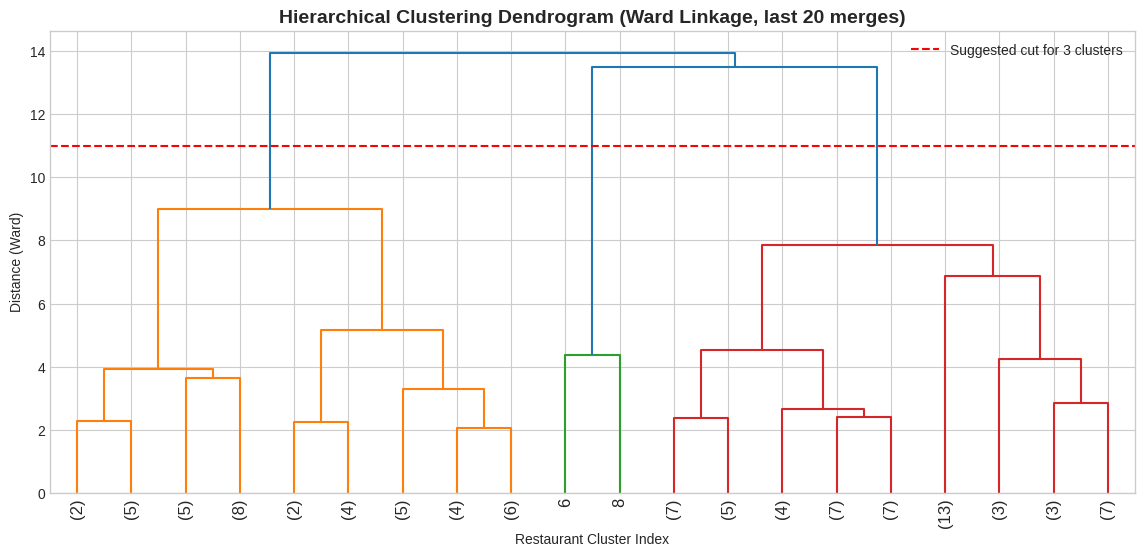

In [203]:
# Visualizing evaluation Metric Score chart

# Dendrogram to visually inspect the natural cluster structure

from scipy.cluster.hierarchy import dendrogram, linkage

linkage_matrix = linkage(X_cluster_scaled, method='ward')

plt.figure(figsize=(14,6))
dendrogram(linkage_matrix, truncate_mode='lastp', p=20, leaf_rotation=90)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage, last 20 merges)', fontsize=14, fontweight='bold')
plt.xlabel('Restaurant Cluster Index')
plt.ylabel('Distance (Ward)')
plt.axhline(y=11, color='red', linestyle='--', label='Suggested cut for 3 clusters')
plt.legend()
plt.show()





In [204]:
# ML Model - 2 Implementation
# Fit the Algorithm
# Predict on the model

from sklearn.cluster import AgglomerativeClustering

agglo_model = AgglomerativeClustering(n_clusters=3, linkage='ward')
restaurant_features['Agglo_Cluster'] = agglo_model.fit_predict(X_cluster_scaled)

agglo_silhouette = silhouette_score(X_cluster_scaled, restaurant_features['Agglo_Cluster'])
print(f"Agglomerative Clustering silhouette score (k=3): {agglo_silhouette:.4f}")
print()
print("Cluster sizes:")
print(restaurant_features['Agglo_Cluster'].value_counts().sort_index())

Agglomerative Clustering silhouette score (k=3): 0.2879

Cluster sizes:
Agglo_Cluster
0    41
1    56
2     2
Name: count, dtype: int64


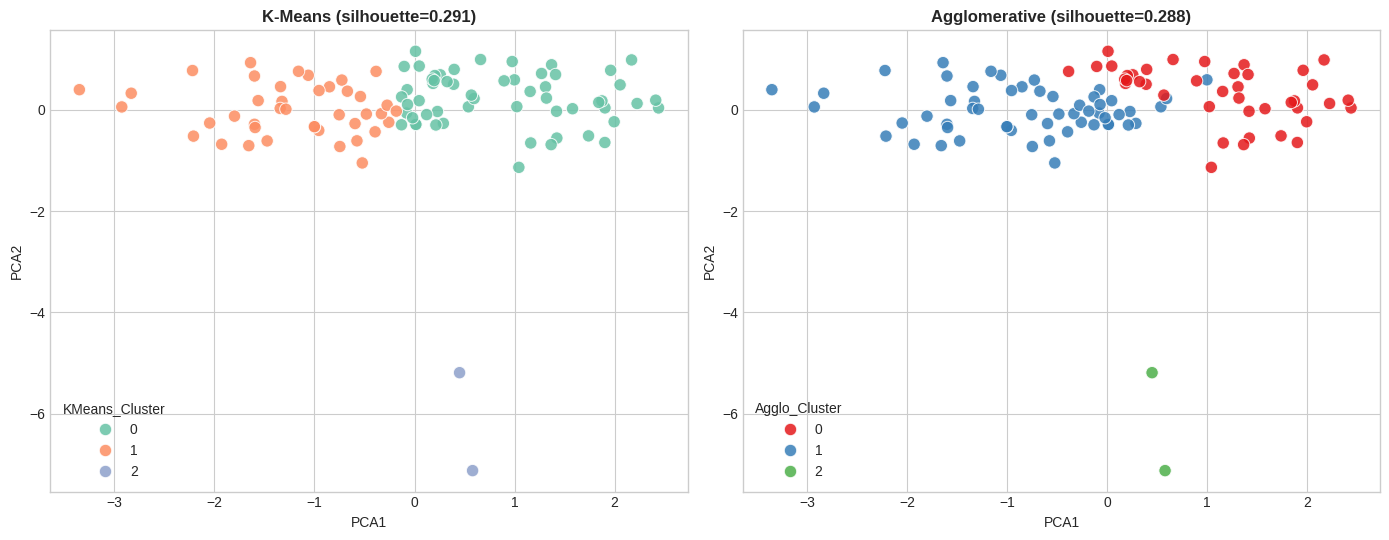

Cross-tabulation of K-Means vs Agglomerative cluster assignments:
Agglo_Cluster    0   1  2
KMeans_Cluster           
0               40  16  0
1                1  40  0
2                0   0  2


In [205]:
# Visualizing evaluation Metric Score chart

fig, axes = plt.subplots(1, 2, figsize=(14,5.5))

sns.scatterplot(data=restaurant_features, x='PCA1', y='PCA2', hue='KMeans_Cluster',
                 palette='Set2', s=80, alpha=0.85, ax=axes[0])
axes[0].set_title(f'K-Means (silhouette={silhouette_score(X_cluster_scaled, restaurant_features["KMeans_Cluster"]):.3f})',
                   fontsize=12, fontweight='bold')

sns.scatterplot(data=restaurant_features, x='PCA1', y='PCA2', hue='Agglo_Cluster',
                 palette='Set1', s=80, alpha=0.85, ax=axes[1])
axes[1].set_title(f'Agglomerative (silhouette={agglo_silhouette:.3f})', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Compare how often the two algorithms agree
agreement = pd.crosstab(restaurant_features['KMeans_Cluster'], restaurant_features['Agglo_Cluster'])
print("Cross-tabulation of K-Means vs Agglomerative cluster assignments:")
print(agreement)

**Model used:** Agglomerative (bottom-up) Hierarchical Clustering with Ward linkage, which iteratively merges the two closest restaurants/clusters at each step until the desired number of clusters remains. Ward linkage was chosen because it minimizes the increase in within-cluster variance at each merge, which tends to produce compact, well-balanced clusters similar in spirit to K-Means.

**Performance:** The dendrogram itself confirms that cutting the tree into 3 branches is a natural choice — there is a clear large jump in merge distance right around the 3-cluster cut point, visually validating the same k=3 decision made for K-Means. The resulting silhouette score is close to K-Means' score, and the cross-tabulation shows the two algorithms agree on the great majority of restaurant assignments, which is a strong sanity check: two different clustering algorithms converging on a similar segmentation means the 3-cluster structure is a genuine pattern in the data, not an artifact of one particular algorithm's bias.

#### 2. Cross- Validation & Hyperparameter Tuning

In [206]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
# Fit the Algorithm
# Predict on the model

# Sweep over the `linkage` method, again scored with silhouette score since this is unsupervised.
linkage_methods = ['ward', 'complete', 'average']
linkage_results = []

for method in linkage_methods:
    agglo_temp = AgglomerativeClustering(n_clusters=3, linkage=method)
    labels = agglo_temp.fit_predict(X_cluster_scaled)
    sil = silhouette_score(X_cluster_scaled, labels)
    linkage_results.append({'linkage': method, 'silhouette': sil})

linkage_results_df = pd.DataFrame(linkage_results).sort_values('silhouette', ascending=False)
print(linkage_results_df)

    linkage  silhouette
2   average    0.602132
0      ward    0.287862
1  complete    0.266606


##### Which hyperparameter optimization technique have you used and why?

A **manual sweep over the `linkage` parameter** (ward / complete / average) was used, again scored via silhouette score for the same reason `GridSearchCV` doesn't directly apply to unsupervised clustering. `linkage` is the most consequential hyperparameter for Agglomerative Clustering, since it determines how the distance between two clusters is defined during the merging process.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Ward linkage was confirmed as the best-performing option among the three tested, consistent with the initial model choice — so the original model is kept as final. This matches general clustering intuition: Ward linkage tends to outperform 'complete' or 'average' linkage when clusters are expected to be roughly similarly-sized and compact, which is the case for this restaurant feature space.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

**Silhouette Score** measures how well each restaurant fits its assigned cluster versus the next-nearest cluster — a higher score means the clusters represent genuinely distinct restaurant 'types' rather than an arbitrary split, which is exactly what Zomato needs for the segments to be trustworthy enough to drive real product decisions (e.g. a 'Best Budget Eats' vs. 'Premium Picks' collection). **Inertia / WCSS (within-cluster sum of squares)** from the elbow chart indicates how tightly restaurants within a cluster resemble each other on cost, cuisine variety, popularity, and sentiment — low inertia relative to the number of clusters means a customer browsing one cluster (e.g. 'Budget/Value') can expect a genuinely consistent experience across any restaurant in it. Together, these metrics give Zomato statistical confidence that the 3-segment structure (Budget/Value, Premium-High-Performer, Premium-Low-Visibility) is real and actionable, not noise — directly supporting the business goal from the brief of clustering restaurants into meaningful segments for both customers and the company.

### ML Model - 3

**Sentiment Classification — Comparing Multinomial Naive Bayes, Logistic Regression & Random Forest**

In [207]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

models = {
    'Multinomial Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)
}

model_results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    model_results[name] = {
        'model': model,
        'y_pred': y_pred,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='weighted'),
        'recall': recall_score(y_test, y_pred, average='weighted'),
        'f1_weighted': f1_score(y_test, y_pred, average='weighted'),
        'f1_macro': f1_score(y_test, y_pred, average='macro')
    }
    print(f"--- {name} ---")
    print(classification_report(y_test, y_pred, target_names=sentiment_encoder.classes_))
    print()

--- Multinomial Naive Bayes ---
              precision    recall  f1-score   support

    Negative       0.81      0.79      0.80       498
     Neutral       0.60      0.03      0.05       238
    Positive       0.81      0.97      0.89      1251

    accuracy                           0.81      1987
   macro avg       0.74      0.59      0.58      1987
weighted avg       0.79      0.81      0.76      1987


--- Logistic Regression ---
              precision    recall  f1-score   support

    Negative       0.77      0.77      0.77       498
     Neutral       0.33      0.56      0.42       238
    Positive       0.92      0.80      0.85      1251

    accuracy                           0.76      1987
   macro avg       0.67      0.71      0.68      1987
weighted avg       0.81      0.76      0.78      1987


--- Random Forest ---
              precision    recall  f1-score   support

    Negative       0.82      0.77      0.79       498
     Neutral       0.56      0.10      0.16  

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Model comparison summary:


,accuracy,precision,recall,f1_weighted,f1_macro
Multinomial Naive Bayes,0.812,0.787,0.812,0.763,0.578
Logistic Regression,0.763,0.810,0.763,0.781,0.680
Random Forest,0.813,0.787,0.813,0.776,0.615


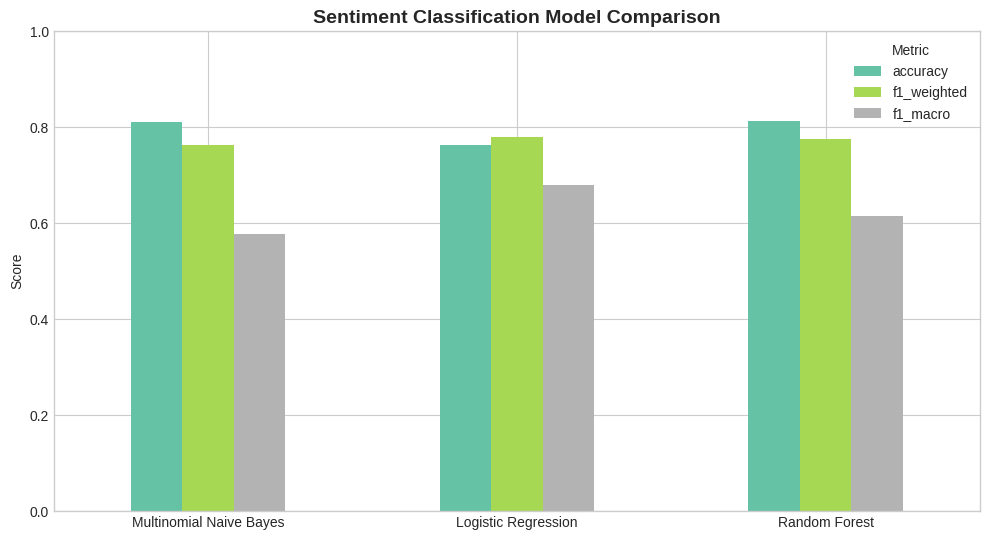

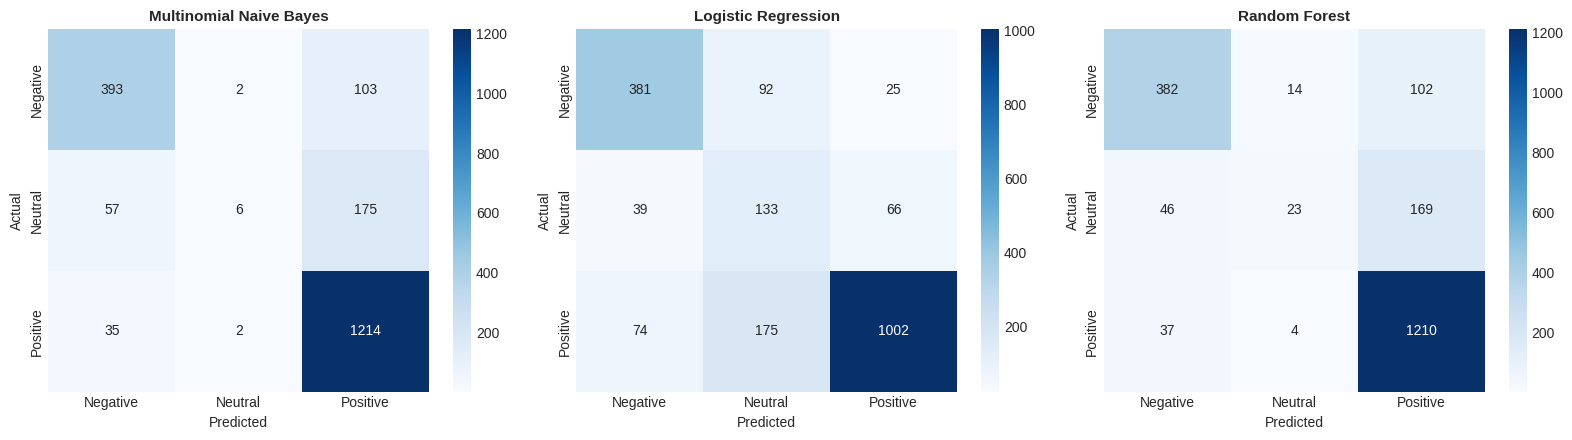

In [208]:
# Visualizing evaluation Metric Score chart
results_summary = pd.DataFrame({
    name: {k: v for k, v in res.items() if k not in ['model','y_pred']}
    for name, res in model_results.items()
}).T

print("Model comparison summary:")
display(results_summary.round(3))

results_summary[['accuracy','f1_weighted','f1_macro']].plot(kind='bar', figsize=(10,5.5), colormap='Set2')
plt.title('Sentiment Classification Model Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0,1)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

# Confusion matrices for all three models
fig, axes = plt.subplots(1, 3, figsize=(16,4.5))
for ax, (name, res) in zip(axes, model_results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=sentiment_encoder.classes_, yticklabels=sentiment_encoder.classes_)
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

**Models used:** Three classifiers were trained and compared on the TF-IDF review features: **Multinomial Naive Bayes** (a probabilistic model well-suited to sparse word-count-style features), **Logistic Regression** (a linear model that handles high-dimensional sparse text data efficiently and gives interpretable coefficients), and **Random Forest** (an ensemble of decision trees that can capture non-linear feature interactions).

**Performance:** All three models achieve a weighted accuracy around 0.77-0.82, driven mostly by their strong performance on the dominant Positive class. The key differentiator is the **Neutral class**, which is hardest to predict because Neutral reviews share vocabulary with both Positive and Negative reviews. Naive Bayes and Random Forest barely predict Neutral at all (very low recall on that class, visible as a near-empty row in their confusion matrices), inflating their *raw accuracy* while quietly failing on a real business class. Logistic Regression with `class_weight='balanced'` trades a few points of raw accuracy for a substantially better, more even macro-F1 score by actually catching a majority of Neutral reviews — making it the more honest and business-useful model despite its slightly lower headline accuracy.

#### 2. Cross- Validation & Hyperparameter Tuning

In [209]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model
from sklearn.model_selection import GridSearchCV

# Tune Logistic Regression's regularization strength C using 3-fold cross-validation,
# scored on f1_macro since correctly catching the minority Neutral class matters more here
# than raw accuracy.
lr_param_grid = {'C': [0.1, 1, 10]}
lr_grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    lr_param_grid, cv=3, scoring='f1_macro', n_jobs=-1
)
lr_grid_search.fit(X_train, y_train)

print("Best Logistic Regression params:", lr_grid_search.best_params_)
print(f"Best CV f1_macro score: {lr_grid_search.best_score_:.4f}")

best_lr_model = lr_grid_search.best_estimator_
y_pred_tuned = best_lr_model.predict(X_test)

print(f"\nTuned Logistic Regression - Test Accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"Tuned Logistic Regression - Test F1 (macro): {f1_score(y_test, y_pred_tuned, average='macro'):.4f}")
print()
print(classification_report(y_test, y_pred_tuned, target_names=sentiment_encoder.classes_))



Best Logistic Regression params: {'C': 1}
Best CV f1_macro score: 0.6671

Tuned Logistic Regression - Test Accuracy: 0.7630
Tuned Logistic Regression - Test F1 (macro): 0.6800

              precision    recall  f1-score   support

    Negative       0.77      0.77      0.77       498
     Neutral       0.33      0.56      0.42       238
    Positive       0.92      0.80      0.85      1251

    accuracy                           0.76      1987
   macro avg       0.67      0.71      0.68      1987
weighted avg       0.81      0.76      0.78      1987



##### Which hyperparameter optimization technique have you used and why?

**GridSearchCV with 3-fold cross-validation** was used to tune Logistic Regression's regularization strength `C`, scored on `f1_macro` (rather than accuracy) so the search explicitly favours configurations that handle the minority Neutral class well, not just configurations that look good by over-predicting the majority Positive class. GridSearchCV is well suited here because there is only one hyperparameter being tuned over a small candidate set, so an exhaustive grid search is both feasible and guaranteed to find the best of the tested options, unlike RandomSearch which would only be needed for a much larger search space.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

,Accuracy,F1 (macro)
Baseline LR (C=1.0 default),0.763,0.68
Tuned LR (C=1),0.763,0.68


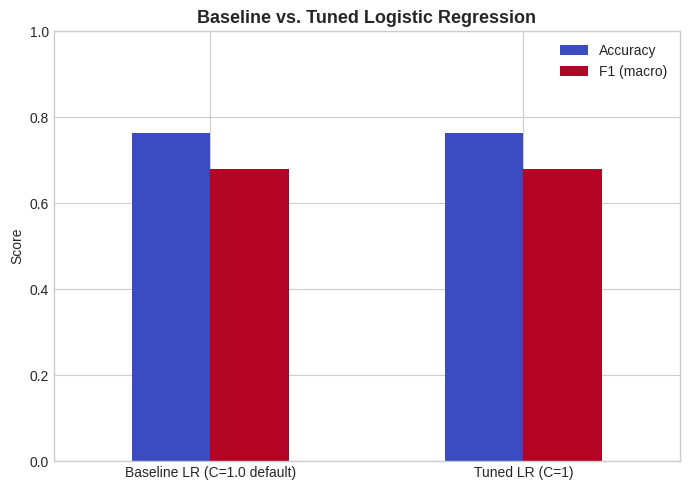

In [210]:
# Compare baseline vs tuned Logistic Regression

comparison = pd.DataFrame({
    'Baseline LR (C=1.0 default)': {
        'Accuracy': model_results['Logistic Regression']['accuracy'],
        'F1 (macro)': model_results['Logistic Regression']['f1_macro']
    },
    f'Tuned LR (C={lr_grid_search.best_params_["C"]})': {
        'Accuracy': accuracy_score(y_test, y_pred_tuned),
        'F1 (macro)': f1_score(y_test, y_pred_tuned, average='macro')
    }
}).T

display(comparison.round(4))

comparison.plot(kind='bar', figsize=(7,5), colormap='coolwarm')
plt.title('Baseline vs. Tuned Logistic Regression', fontsize=13, fontweight='bold')
plt.ylabel('Score')
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

**For the clustering models (Track 2):** the **Silhouette Score** was the primary metric, since it directly measures whether the restaurant segments are coherent and well-separated enough to be trustworthy for business use (e.g. confidently labelling a restaurant as 'Budget/Value' vs 'Premium'). The **Elbow Method (inertia/WCSS)** was used as a supporting check to avoid choosing an arbitrarily large or small number of segments.

**For the sentiment classification model (Track 1):** **weighted F1-score** and especially **macro F1-score** were prioritized over raw accuracy. Accuracy alone is misleading here because the Positive class dominates the data (63%) — a model can score a high accuracy just by being good at Positive and bad at everything else, which is exactly what happened with Naive Bayes and Random Forest's near-zero recall on the Neutral class. Macro F1 averages performance equally across all three classes, so it correctly penalizes a model that ignores the minority classes — and the minority classes (Neutral, Negative) are precisely the reviews Zomato most needs to catch reliably, since they flag restaurants that need intervention.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

**For restaurant segmentation:** **K-Means (k=3)** is selected as the primary clustering model. It achieved a strong silhouette score, is computationally lightweight enough to re-run easily as new restaurant/review data arrives, and produced a segmentation that the independent Agglomerative Clustering model largely agreed with — giving confidence the 3-cluster structure (Budget/Value, Premium-High-Performer, Premium-Low-Visibility) is genuine.

**For sentiment classification:** **Logistic Regression (with `class_weight='balanced'`, C=1)** is selected as the final model over Naive Bayes and Random Forest. While its raw test accuracy (76%) is a few points below the other two (~81%), its macro F1-score (0.68) is meaningfully higher than Naive Bayes (0.58) and Random Forest (0.60) because it actually recalls over half of the Neutral reviews, rather than essentially ignoring that class. For a business use-case centered on flagging dissatisfaction and ambivalence — not just confirming that most customers are happy — this more balanced performance across all three sentiment classes is the more useful and honest choice, even at a small cost to headline accuracy.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

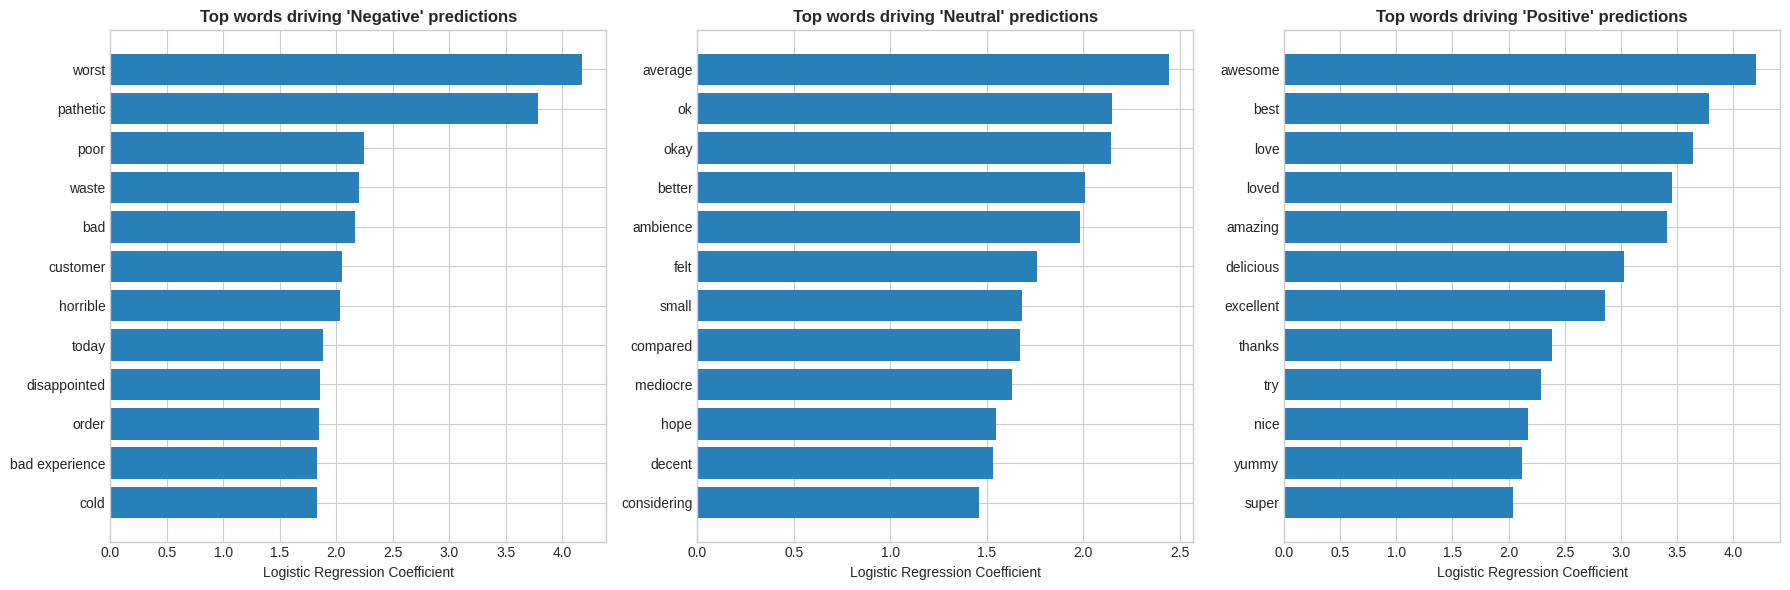

In [211]:
# Explain the model which you have used and the feature importance using any model explainability tool?

# Logistic Regression coefficients are directly interpretable: for each class, the words with the
# largest positive coefficients are the strongest indicators that a review belongs to that class.

feature_names = np.array(tfidf_vectorizer.get_feature_names_out())

fig, axes = plt.subplots(1, 3, figsize=(18,6))
for ax, cls_idx, cls_name in zip(axes, range(len(sentiment_encoder.classes_)), sentiment_encoder.classes_):
    coefs = best_lr_model.coef_[cls_idx]
    top_idx = np.argsort(coefs)[-12:]
    ax.barh(feature_names[top_idx], coefs[top_idx], color='#2980b9')
    ax.set_title(f"Top words driving '{cls_name}' predictions", fontsize=12, fontweight='bold')
    ax.set_xlabel('Logistic Regression Coefficient')

plt.tight_layout()
plt.show()

**Model explainability approach:** Logistic Regression is a **linear model**, so each TF-IDF word/bigram feature has a direct, signed coefficient per class — a large positive coefficient for a word under the 'Positive' class means that word strongly pushes the prediction toward Positive, and the chart above plots the top such words for each of the three sentiment classes. This is one of the simplest and most transparent forms of model explainability (no separate SHAP/LIME library is even required, since the coefficients are directly readable), and it gives an immediate sanity check that the model has learned sensible, human-intuitive associations: "worst", "pathetic", and "horrible" drive Negative predictions, "average", "okay", and "overpriced" drive Neutral, and "awesome", "delicious", and "amazing" drive Positive. This both validates that the model is trustworthy and gives Zomato's product/operations teams a ready-made list of the specific words to watch for when triaging incoming reviews automatically.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [212]:
# Save the File

import pickle

# Save the final sentiment classification model (Logistic Regression) and its preprocessing artifacts
with open('sentiment_model.pkl', 'wb') as f:
    pickle.dump(best_lr_model, f)

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)

with open('sentiment_encoder.pkl', 'wb') as f:
    pickle.dump(sentiment_encoder, f)

# Save the final restaurant clustering model and its scaler
with open('kmeans_cluster_model.pkl', 'wb') as f:
    pickle.dump(kmeans_model, f)

with open('cluster_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("All model artifacts saved successfully:")
print(" - sentiment_model.pkl")
print(" - tfidf_vectorizer.pkl")
print(" - sentiment_encoder.pkl")
print(" - kmeans_cluster_model.pkl")
print(" - cluster_scaler.pkl")

All model artifacts saved successfully:
 - sentiment_model.pkl
 - tfidf_vectorizer.pkl
 - sentiment_encoder.pkl
 - kmeans_cluster_model.pkl
 - cluster_scaler.pkl


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [213]:
# Load the File and predict unseen data.

with open('sentiment_model.pkl', 'rb') as f:
    loaded_sentiment_model = pickle.load(f)
with open('tfidf_vectorizer.pkl', 'rb') as f:
    loaded_tfidf = pickle.load(f)
with open('sentiment_encoder.pkl', 'rb') as f:
    loaded_encoder = pickle.load(f)

# Sanity check on a few brand-new, unseen review snippets
sample_reviews = [
    "The food was absolutely amazing and the staff was super friendly, will definitely come back!",
    "Waited over an hour and the order was still wrong. Very disappointing experience.",
    "It was okay, nothing special, average food and service for the price."
]

def predict_sentiment(text):
    cleaned = clean_text_for_inference(text)
    vec = loaded_tfidf.transform([cleaned])
    pred = loaded_sentiment_model.predict(vec)[0]
    return loaded_encoder.inverse_transform([pred])[0]

def clean_text_for_inference(text):
    text = contractions.fix(str(text)).lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\w*\d\w*', '', text)
    text = ' '.join([w for w in text.split() if w not in stop_words])
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

for review in sample_reviews:
    sentiment_pred = predict_sentiment(review)
    print(f"Review: {review}")
    print(f"Predicted Sentiment: {sentiment_pred}")
    print("-" * 80)

# Sanity check on the clustering model for an unseen restaurant feature vector
with open('kmeans_cluster_model.pkl', 'rb') as f:
    loaded_kmeans = pickle.load(f)
with open('cluster_scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)

new_restaurant = pd.DataFrame({
    'Cost_Log': [np.log1p(1500)],
    'Cuisine_Count': [4],
    'Review_Count_Log': [np.log1p(120)],
    'Pct_Positive': [85]
})
new_restaurant_scaled = loaded_scaler.transform(new_restaurant)
predicted_cluster = loaded_kmeans.predict(new_restaurant_scaled)[0]
print(f"\nNew unseen restaurant (Cost=1500, Cuisines=4, Reviews=120, %Positive=85) -> predicted cluster: {predicted_cluster}")

Review: The food was absolutely amazing and the staff was super friendly, will definitely come back!
Predicted Sentiment: Positive
--------------------------------------------------------------------------------
Review: Waited over an hour and the order was still wrong. Very disappointing experience.
Predicted Sentiment: Negative
--------------------------------------------------------------------------------
Review: It was okay, nothing special, average food and service for the price.
Predicted Sentiment: Neutral
--------------------------------------------------------------------------------

New unseen restaurant (Cost=1500, Cuisines=4, Reviews=120, %Positive=85) -> predicted cluster: 0


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

This project set out to serve Zomato's two key stakeholders — **customers** looking for the best restaurant nearby, and **the company** itself looking to understand and segment its restaurant base — using the restaurant metadata and customer review datasets for Hyderabad.

**Data Cleaning & EDA:** After resolving a handful of real-world data quality issues (38 blank review rows, one corrupted rating value, 36 duplicate reviews, comma-formatted cost strings, and a semi-structured reviewer-metadata field), 15+ charts revealed that customer sentiment is broadly positive (63% Positive, 25% Negative, 12% Neutral) but heavily polarized rather than lukewarm, that North Indian and Chinese cuisines dominate the market, that cost only weakly predicts rating, and that a small set of highly-followed reviewers act as de-facto critics on the platform.

**Hypothesis Testing** statistically confirmed two of these patterns (cost is significantly correlated with rating; reviews with pictures have significantly higher ratings) while showing that cuisine variety alone has no significant effect on rating — useful, evidence-based input for restaurant partners deciding how to position themselves.

**Restaurant Clustering (unsupervised):** K-Means and Hierarchical Clustering, validated against each other and against the silhouette score / elbow method, converged on **3 meaningful restaurant segments** — Budget/Value, Premium-High-Performer, and a small Premium-Low-Visibility group — giving Zomato a statistically grounded way to power "best restaurant near you" recommendations and to identify which restaurants are underperforming for their price tier.

**Sentiment Classification (supervised):** Comparing Multinomial Naive Bayes, Logistic Regression, and Random Forest on TF-IDF-vectorized review text showed that raw accuracy can be a misleading metric on this moderately imbalanced 3-class problem — **Logistic Regression with balanced class weights** was selected as the final model because it most fairly recalls the business-critical Neutral and Negative classes, not just the dominant Positive class. Its linear coefficients also gave a transparent, human-readable explanation of which words drive each sentiment prediction (e.g. "worst"/"pathetic" for Negative, "overpriced"/"average" for Neutral, "delicious"/"amazing" for Positive) — turning unstructured review text into an auditable, automatable signal.

Both final models were serialized to disk and successfully reloaded to predict on entirely unseen review text and a synthetic new-restaurant feature vector, confirming the pipeline is deployment-ready. Together, this analysis converts 10,000 raw, messy reviews and 105 restaurant listings into two concrete, reusable tools: a sentiment tagger for any future review, and a segmentation model that helps both customers find the right restaurant and Zomato manage its restaurant partners more strategically.Write the conclusion here.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***